# RQ3: How Does Dimensionality Affect RFM Behaviour Across Curvatures?

Investigates how **intrinsic dimensionality** interacts with **curvature** to shape RFM behaviour across four datasets: GtG, MoG, Checkerboard, and Gaussian Ring.

## Setup

In [50]:
from visualize_run import get_metrics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [51]:
PERF_COL     = "test_sample/sinkhorn_knopp"
VGG_COL      = "test_sample/volume_scaling_gap_target_minus_pred"
DIM_COL      = "dim"
MANIFOLD_COL = "manifold"
CURV_COL     = "curvature"

EUCLIDEAN_NAME = "euclidean"
POINCARE_NAME  = "poincare"
SPHERE_NAME    = "sphere"

SPHERE_DIM_MINUS_ONE = True
ERROR_BAR            = "sem"
SELECTED_CURVATURES  = [1, 3, 10]
CURVATURE_ORDER      = "abs"

DATASET_PATHS = {
    "GtG":           "runs/gtg/metrics.csv",
    "MoG":           "runs/mog/metrics.csv",
    "Checkerboard":  "runs/checkerboard/metrics.csv",
    "Gaussian Ring": "runs/gaussian_ring/metrics.csv",
}

DATASET_COLORS  = ["#1D9E75", "#D85A30", "#185FA5", "#854F0B"]
DATASET_MARKERS = ["o", "s", "^", "D"]

In [52]:
def signed_log1p(x):
    return np.sign(x) * np.log10(1 + np.abs(x))

def safe_log10(x):
    x = pd.to_numeric(x, errors="coerce")
    return np.log10(x.where(x > 0))

def error_value(x, kind="sem"):
    x = pd.Series(x).replace([np.inf, -np.inf], np.nan).dropna()
    if len(x) <= 1: return 0.0
    if kind == "std": return x.std(ddof=1)
    return x.std(ddof=1) / np.sqrt(len(x))

def mean_sem(x):
    x = pd.Series(x).replace([np.inf, -np.inf], np.nan).dropna()
    if len(x) == 0: return np.nan, np.nan, 0
    mean = x.mean()
    if len(x) == 1: return mean, 0.0, 1
    return mean, x.std(ddof=1) / np.sqrt(len(x)), len(x)

def nice_dim_label(x):
    if pd.isna(x): return ""
    return str(int(x)) if float(x).is_integer() else f"{x:g}"

def nice_curv_label(x):
    if pd.isna(x): return "NA"
    try: return f"{float(x):g}"
    except Exception: return str(x)

def display_manifold_name(m):
    return {POINCARE_NAME: "Hyperbolic", SPHERE_NAME: "Spherical",
            EUCLIDEAN_NAME: "Euclidean"}.get(m, str(m))

def ordered_curvatures(values, order="abs"):
    values = pd.Series(values).dropna().unique()
    def key(x):
        try:
            xf = float(x)
            return (abs(xf), xf) if order == "abs" else (xf,)
        except Exception: return (str(x),)
    return sorted(values, key=key)

def ordered_manifolds(values):
    preferred = [POINCARE_NAME, SPHERE_NAME, EUCLIDEAN_NAME]
    values = list(pd.Series(values).dropna().unique())
    return [m for m in preferred if m in values] + [m for m in values if m not in preferred]

def ordered_values_numeric(values, use_abs=False):
    values = pd.Series(values).dropna().unique()
    def key(x):
        try:
            xf = float(x)
            return (abs(xf), xf) if use_abs else (xf,)
        except Exception: return (str(x),)
    return sorted(values, key=key)

In [53]:
def add_relative_to_euclidean(df_prepared, metric_col, out_col):
    df = df_prepared.copy()
    euc = (
        df[df[MANIFOLD_COL].eq(EUCLIDEAN_NAME)]
        .groupby("compare_dim", as_index=False)
        .agg(euc_metric=(metric_col, "mean"))
    )
    df = df.merge(euc, on="compare_dim", how="left")
    df[out_col] = df[metric_col] / df["euc_metric"]
    return df

def prepare_rq3_dataframe(df):
    df = df.copy()
    df[PERF_COL] = pd.to_numeric(df[PERF_COL], errors="coerce")
    df[VGG_COL]  = pd.to_numeric(df[VGG_COL],  errors="coerce")
    df[DIM_COL]  = pd.to_numeric(df[DIM_COL],  errors="coerce")

    df["compare_dim"] = df[DIM_COL]
    if SPHERE_DIM_MINUS_ONE:
        mask = df[MANIFOLD_COL].eq(SPHERE_NAME)
        df.loc[mask, "compare_dim"] = df.loc[mask, DIM_COL] - 1

    euc = (
        df[df[MANIFOLD_COL].eq(EUCLIDEAN_NAME)]
        .groupby("compare_dim", as_index=False)
        .agg(euc_perf=(PERF_COL, "mean"), euc_vgg=(VGG_COL, "mean"))
    )
    euc["euc_vgg"] = euc["euc_vgg"].fillna(0.0)
    df = df.merge(euc, on="compare_dim", how="left")

    df["rel_perf"]           = df[PERF_COL] / df["euc_perf"]
    df["log_rel_perf"]       = np.log10(df["rel_perf"])
    df["vgg_gap_vs_euc"]     = df[VGG_COL] - df["euc_vgg"]
    df["signed_log_vgg_gap"] = signed_log1p(df["vgg_gap_vs_euc"])
    return df

In [54]:
def make_curvature_dimension_surface(
    df_prepared, metric_col, value_col_name="value",
    relative_to_euclidean=False, log10_value=False,
    signed_log_value=False, exclude_euclidean=True,
):
    df = df_prepared.copy()
    df[metric_col] = pd.to_numeric(df[metric_col], errors="coerce")
    if relative_to_euclidean:
        rel_col = f"{metric_col}_rel_euc"
        df = add_relative_to_euclidean(df, metric_col, rel_col)
        base_col = rel_col
    else:
        base_col = metric_col
    if log10_value:
        df[value_col_name] = safe_log10(df[base_col])
    elif signed_log_value:
        df[value_col_name] = signed_log1p(df[base_col])
    else:
        df[value_col_name] = df[base_col]
    if exclude_euclidean:
        df = df[~df[MANIFOLD_COL].eq(EUCLIDEAN_NAME)].copy()
    rows = []
    for keys, sub in df.groupby([MANIFOLD_COL, CURV_COL, "compare_dim"], dropna=False):
        manifold, curvature, dim = keys
        mean, sem, n = mean_sem(sub[value_col_name])
        rows.append({MANIFOLD_COL: manifold, CURV_COL: curvature,
                     "compare_dim": dim, "mean": mean, "sem": sem, "n": n})
    return pd.DataFrame(rows)


def plot_curvature_dimension_heatmaps(
    surface_df, title, cbar_label,
    manifolds=(POINCARE_NAME, SPHERE_NAME),
    annotate=True, cmap="RdBu_r", curvature_order_abs=True,
):
    manifolds = [m for m in manifolds if m in surface_df[MANIFOLD_COL].unique()]
    fig, axes = plt.subplots(1, len(manifolds),
                             figsize=(6.2 * len(manifolds), 4.2), squeeze=False)
    axes = axes[0]
    vals = surface_df["mean"].replace([np.inf, -np.inf], np.nan)
    abs_max = max(abs(np.nanmin(vals)), abs(np.nanmax(vals)))
    vmin, vmax = -abs_max, abs_max

    for ax, manifold in zip(axes, manifolds):
        sub = surface_df[surface_df[MANIFOLD_COL].eq(manifold)].copy()
        dims       = ordered_values_numeric(sub["compare_dim"])
        curvatures = ordered_values_numeric(sub[CURV_COL], use_abs=curvature_order_abs)
        pivot = (
            sub.pivot_table(index=CURV_COL, columns="compare_dim",
                            values="mean", aggfunc="mean")
            .reindex(index=curvatures, columns=dims)
        )
        im = ax.imshow(pivot.values, aspect="auto", cmap=cmap,
                       vmin=vmin, vmax=vmax, interpolation="nearest")
        ax.set_xticks(range(len(dims)))
        ax.set_xticklabels([nice_dim_label(d) for d in dims], rotation=45, ha="right")
        ax.set_yticks(range(len(curvatures)))
        ax.set_yticklabels([nice_curv_label(c) for c in curvatures])
        ax.set_xlabel("Dimension")
        ax.set_ylabel("Curvature |k|")
        ax.set_title(display_manifold_name(manifold))
        if annotate:
            for ri in range(pivot.shape[0]):
                for ci in range(pivot.shape[1]):
                    val = pivot.iloc[ri, ci]
                    if not np.isnan(val):
                        tc = "white" if abs(val) > 0.45 * abs_max else "black"
                        ax.text(ci, ri, f"{val:.2f}",
                                ha="center", va="center", fontsize=7.5, color=tc)
        plt.colorbar(im, ax=ax, label=cbar_label, shrink=0.85)
    fig.suptitle(title, fontsize=13, y=1.02)
    fig.tight_layout()
    return fig, axes


def plot_wasserstein_vs_dim(df_prepared, selected_curvatures=None, title_suffix=""):
    df = df_prepared[~df_prepared[MANIFOLD_COL].eq(EUCLIDEAN_NAME)].copy()
    df = df.replace([np.inf, -np.inf], np.nan)
    if selected_curvatures is not None:
        df = df[df[CURV_COL].isin(selected_curvatures)]

    manifolds = [m for m in ordered_manifolds(df[MANIFOLD_COL]) if m != EUCLIDEAN_NAME]
    grouped = (
        df.groupby([MANIFOLD_COL, CURV_COL, "compare_dim"], as_index=False)
        .agg(
            y_mean=("log_rel_perf", "mean"),
            y_sem=("log_rel_perf",  lambda x: error_value(x, ERROR_BAR)),
            n=("log_rel_perf", "count"),
        )
    )

    all_curvs = ordered_curvatures(grouped[CURV_COL], order=CURVATURE_ORDER)
    cmap_fn   = plt.cm.viridis
    color_map = {c: cmap_fn(v) for c, v in
                 zip(all_curvs, np.linspace(0.1, 0.9, len(all_curvs)))}

    fig, axes = plt.subplots(1, len(manifolds),
                             figsize=(6.5 * len(manifolds), 4.8), sharey=True)
    if len(manifolds) == 1: axes = [axes]

    for ax, manifold in zip(axes, manifolds):
        sub_m = grouped[grouped[MANIFOLD_COL].eq(manifold)]
        for curvature in ordered_curvatures(sub_m[CURV_COL], order=CURVATURE_ORDER):
            sub = sub_m[sub_m[CURV_COL].eq(curvature)].sort_values("compare_dim")
            if sub.empty: continue
            color = color_map[curvature]
            d, ym, ys = sub["compare_dim"].values, sub["y_mean"].values, sub["y_sem"].values
            ax.fill_between(d, ym - ys, ym + ys, alpha=0.15, color=color)
            ax.errorbar(d, ym, yerr=ys, fmt="o-", color=color, markersize=6,
                        capsize=4, linewidth=2, label=f"k={nice_curv_label(curvature)}")
        ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.6)
        ax.set_xscale("log", base=2)
        dims_all = sorted(sub_m["compare_dim"].dropna().unique())
        ax.set_xticks(dims_all)
        ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
        ax.set_xlabel("Intrinsic dimension", fontsize=11)
        ax.set_title(display_manifold_name(manifold), fontsize=12)
        ax.legend(frameon=False, title="Curvature", fontsize=9)
        ax.grid(alpha=0.2)
        ax.text(0.02, 0.98, "Above 0: worse than Euclidean\nBelow 0: better than Euclidean",
                transform=ax.transAxes, fontsize=8, va="top", color="grey")

    axes[0].set_ylabel("log10(Wasserstein / Euclidean baseline)", fontsize=11)
    suffix = f" — {title_suffix}" if title_suffix else ""
    fig.suptitle(f"RQ3: Wasserstein vs. dimensionality{suffix}", fontsize=14)
    fig.tight_layout()
    return fig, axes


def plot_stability_heatmaps(df_prepared, title_prefix=""):
    df = df_prepared.copy()
    df["nan_rate"] = 1.0 - pd.to_numeric(df.get("test_vec/finite_fraction"), errors="coerce")
    df["log_norm"] = safe_log10(pd.to_numeric(df.get("test_vec/norm_mean"),   errors="coerce"))

    metric_specs = [
        ("nan_rate", "NaN rate (1 - finite_fraction)", "Reds"),
        ("log_norm", "log10(vector field norm mean)",  "viridis"),
    ]
    manifolds = [m for m in [POINCARE_NAME, SPHERE_NAME]
                 if m in df[MANIFOLD_COL].unique()]

    fig, axes = plt.subplots(len(metric_specs), len(manifolds),
                             figsize=(6.2 * len(manifolds), 4.0 * len(metric_specs)),
                             squeeze=False)

    for row_i, (metric_col, cbar_label, cmap_name) in enumerate(metric_specs):
        sub_df = df[~df[MANIFOLD_COL].eq(EUCLIDEAN_NAME)].copy()
        rows = []
        for keys, sub in sub_df.groupby([MANIFOLD_COL, CURV_COL, "compare_dim"], dropna=False):
            m_name, curv, dim = keys
            mean, sem, n = mean_sem(sub[metric_col].replace([np.inf, -np.inf], np.nan))
            rows.append({MANIFOLD_COL: m_name, CURV_COL: curv,
                         "compare_dim": dim, "mean": mean})
        surface = pd.DataFrame(rows)
        vals = surface["mean"].replace([np.inf, -np.inf], np.nan)
        vmin, vmax = np.nanmin(vals), np.nanmax(vals)

        for col_i, manifold in enumerate(manifolds):
            ax = axes[row_i][col_i]
            sub_m = surface[surface[MANIFOLD_COL].eq(manifold)]
            dims       = ordered_values_numeric(sub_m["compare_dim"])
            curvatures = ordered_values_numeric(sub_m[CURV_COL], use_abs=True)
            pivot = (
                sub_m.pivot_table(index=CURV_COL, columns="compare_dim",
                                  values="mean", aggfunc="mean")
                .reindex(index=curvatures, columns=dims)
            )
            im = ax.imshow(pivot.values, aspect="auto", cmap=cmap_name,
                           vmin=vmin, vmax=vmax, interpolation="nearest")
            ax.set_xticks(range(len(dims)))
            ax.set_xticklabels([nice_dim_label(d) for d in dims], rotation=45, ha="right")
            ax.set_yticks(range(len(curvatures)))
            ax.set_yticklabels([nice_curv_label(c) for c in curvatures])
            ax.set_xlabel("Dimension")
            ax.set_ylabel("Curvature |k|")
            ax.set_title(f"{display_manifold_name(manifold)} | {cbar_label}", fontsize=9)
            for ri in range(pivot.shape[0]):
                for ci in range(pivot.shape[1]):
                    v = pivot.iloc[ri, ci]
                    if not np.isnan(v):
                        ax.text(ci, ri, f"{v:.2f}", ha="center", va="center", fontsize=7)
            plt.colorbar(im, ax=ax, label=cbar_label, shrink=0.85)

    prefix = f"[{title_prefix}] " if title_prefix else ""
    fig.suptitle(f"{prefix}Appendix A: Stability diagnostics", fontsize=13, y=1.01)
    fig.tight_layout()
    return fig, axes


def plot_vgg_and_wasserstein_vs_dim(df_prepared, selected_curvatures=None, title_prefix=""):
    df = df_prepared[~df_prepared[MANIFOLD_COL].eq(EUCLIDEAN_NAME)].copy()
    df = df.replace([np.inf, -np.inf], np.nan)
    if selected_curvatures is not None:
        df = df[df[CURV_COL].isin(selected_curvatures)]

    manifolds  = [m for m in ordered_manifolds(df[MANIFOLD_COL]) if m != EUCLIDEAN_NAME]
    all_curvs  = ordered_curvatures(df[CURV_COL], order=CURVATURE_ORDER)
    cmap_fn    = plt.cm.plasma
    color_map  = {c: cmap_fn(v) for c, v in
                  zip(all_curvs, np.linspace(0.05, 0.92, len(all_curvs)))}

    grouped = (
        df.groupby([MANIFOLD_COL, CURV_COL, "compare_dim"], as_index=False)
        .agg(
            vgg_mean=("signed_log_vgg_gap", "mean"),
            vgg_sem=("signed_log_vgg_gap",  lambda x: error_value(x, ERROR_BAR)),
            wass_mean=("log_rel_perf", "mean"),
            wass_sem=("log_rel_perf",  lambda x: error_value(x, ERROR_BAR)),
            n=(PERF_COL, "count"),
        )
    )

    row_specs = [
        ("vgg_mean",  "vgg_sem",  "sgn(dVGG)*log10(1+|dVGG|)"),
        ("wass_mean", "wass_sem", "log10(Wasserstein / Euclidean)"),
    ]

    fig, axes = plt.subplots(2, len(manifolds),
                             figsize=(6.5 * len(manifolds), 4.5 * 2),
                             sharey="row", squeeze=False)

    for col_i, manifold in enumerate(manifolds):
        sub_m      = grouped[grouped[MANIFOLD_COL].eq(manifold)]
        curvatures = ordered_curvatures(sub_m[CURV_COL], order=CURVATURE_ORDER)
        dims_all   = sorted(sub_m["compare_dim"].dropna().unique())

        for row_i, (y_col, e_col, ylabel) in enumerate(row_specs):
            ax = axes[row_i][col_i]
            for curvature in curvatures:
                sub = sub_m[sub_m[CURV_COL].eq(curvature)].sort_values("compare_dim")
                if sub.empty: continue
                color = color_map[curvature]
                d, ym, ys = sub["compare_dim"].values, sub[y_col].values, sub[e_col].values
                ax.fill_between(d, ym - ys, ym + ys, alpha=0.12, color=color)
                ax.errorbar(d, ym, yerr=ys, fmt="o-", color=color, markersize=5,
                            capsize=3, linewidth=1.8,
                            label=f"k={nice_curv_label(curvature)}")
            ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.55)
            ax.set_xscale("log", base=2)
            ax.set_xticks(dims_all)
            ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
            ax.set_xlabel("Intrinsic dimension")
            ax.grid(alpha=0.2)
            if col_i == 0:
                ax.set_ylabel(ylabel, fontsize=10)
            if row_i == 0:
                ax.set_title(display_manifold_name(manifold), fontsize=12)
            if col_i == len(manifolds) - 1:
                ax.legend(frameon=False, title="Curvature", fontsize=8,
                          loc="upper left", bbox_to_anchor=(1.01, 1))

    prefix = f"[{title_prefix}] " if title_prefix else ""
    fig.suptitle(
        f"{prefix}Appendix C: VGG and Wasserstein vs. dimensionality\n"
        "Does performance track volume scaling?",
        fontsize=13, y=1.01,
    )
    fig.tight_layout()
    return fig, axes


def make_spearman_by_dim_table(df_prepared):
    df = df_prepared[~df_prepared[MANIFOLD_COL].eq(EUCLIDEAN_NAME)].copy()
    df = df.replace([np.inf, -np.inf], np.nan)

    grouped = (
        df.groupby(["compare_dim", MANIFOLD_COL, CURV_COL], as_index=False)
        .agg(wass=("log_rel_perf", "mean"), vgg=("signed_log_vgg_gap", "mean"))
    )

    dims = sorted(grouped["compare_dim"].dropna().unique())
    rows = []
    for dim in dims:
        sub = grouped[grouped["compare_dim"].eq(dim)].dropna(subset=["wass", "vgg"])
        n   = len(sub)
        if n >= 3:
            rho, pval = stats.spearmanr(sub["vgg"], sub["wass"])
        else:
            rho, pval = np.nan, np.nan
        rows.append({
            "Dimension":     int(dim) if float(dim).is_integer() else dim,
            "n experiments": n,
            "Spearman rho":  round(rho, 3) if not np.isnan(rho) else "---",
            "p-value":       f"{pval:.3f}" if not np.isnan(pval) else "---",
        })

    pooled      = grouped.dropna(subset=["wass", "vgg"])
    rho_all, pval_all = (stats.spearmanr(pooled["vgg"], pooled["wass"])
                         if len(pooled) >= 3 else (np.nan, np.nan))
    rows.append({
        "Dimension":     "All (pooled)",
        "n experiments": len(pooled),
        "Spearman rho":  round(rho_all, 3) if not np.isnan(rho_all) else "---",
        "p-value":       f"{pval_all:.3f}" if not np.isnan(pval_all) else "---",
    })
    return pd.DataFrame(rows)


def make_training_time_table(df_raw, df_prepared):
    time_candidates = [c for c in df_raw.columns if "nfe" in c.lower()]
    if not time_candidates:
        print("No NFE column found.")
        return None
    time_col = time_candidates[0]
    df       = df_prepared.copy()
    df["_time"] = pd.to_numeric(df_raw[time_col], errors="coerce")
    rows = []
    for (manifold, dim), sub in df.groupby([MANIFOLD_COL, "compare_dim"]):
        t             = sub["_time"].replace([np.inf, -np.inf], np.nan).dropna()
        mean, sem, n  = mean_sem(t)
        rows.append({
            "Manifold":  display_manifold_name(manifold),
            "Dimension": int(dim) if float(dim).is_integer() else dim,
            "Mean NFE":  f"{mean:.1f}" if not np.isnan(mean) else "---",
            "SEM":       f"{sem:.1f}"  if not np.isnan(sem)  else "---",
            "n runs":    n,
        })
    return pd.DataFrame(rows).sort_values(["Manifold", "Dimension"]).reset_index(drop=True)

## Data loading

In [55]:
prepared = {}
raw      = {}

for name, path in DATASET_PATHS.items():
    try:
        df_raw  = pd.read_csv(path)
        df_prep = prepare_rq3_dataframe(df_raw)
        prepared[name] = df_prep
        raw[name]      = df_raw
        print(f"[OK]   {name:15s}  {len(df_prep)} rows | "
              f"dims={sorted(df_prep['compare_dim'].dropna().unique())} | "
              f"curvatures={sorted(df_prep[CURV_COL].dropna().unique())}")
    except FileNotFoundError:
        print(f"[SKIP] {name} — file not found: {path}")
    except Exception as e:
        print(f"[ERR]  {name} — {e}")

[OK]   GtG              243 rows | dims=[2, 3, 4, 8, 16, 64, 256, 512] | curvatures=[0.0, 1.0, 2.0, 3.0, 5.0, 10.0]
[OK]   MoG              1124 rows | dims=[2, 3, 16, 64, 256, 512] | curvatures=[0.0, 1.0, 2.0, 3.0, 5.0, 10.0]
[OK]   Checkerboard     55 rows | dims=[2] | curvatures=[0.0, 1.0, 2.0, 3.0, 5.0, 10.0]
[OK]   Gaussian Ring    582 rows | dims=[2, 3, 16, 64, 256, 512] | curvatures=[0, 1, 2, 3, 5, 10]


---
## Section 1 — GtG (Gaussians-to-Gaussians)

### Wasserstein surface — curvature × dimension

Heatmap of `log10(Wasserstein / Euclidean baseline)`. Red = worse than flat, blue = better. Rows = curvature magnitude, columns = intrinsic dimension.

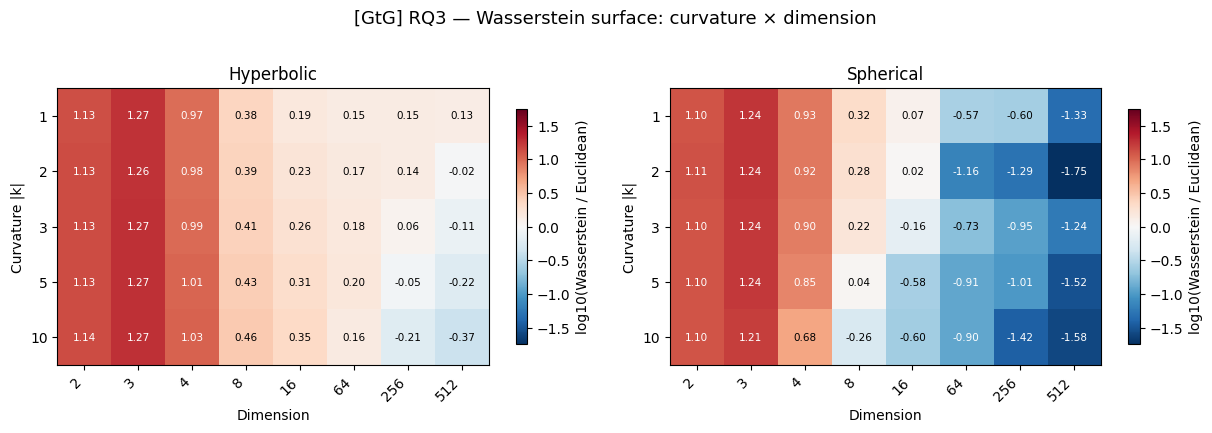

In [56]:
_df = prepared.get("GtG")
if _df is not None:
    _surf = make_curvature_dimension_surface(
        _df, metric_col=PERF_COL,
        value_col_name="log_rel_wasserstein",
        relative_to_euclidean=True, log10_value=True,
    )
    fig, _ = plot_curvature_dimension_heatmaps(
        _surf,
        title="[GtG] RQ3 — Wasserstein surface: curvature × dimension",
        cbar_label="log10(Wasserstein / Euclidean)",
    )
    plt.show()

### Wasserstein vs. dimensionality — selected curvatures

Line plot for k ∈ {1, 3, 10}. x-axis is intrinsic dimension (log₂ scale). Shaded bands = ±SEM. Dashed line at 0 = parity with Euclidean.

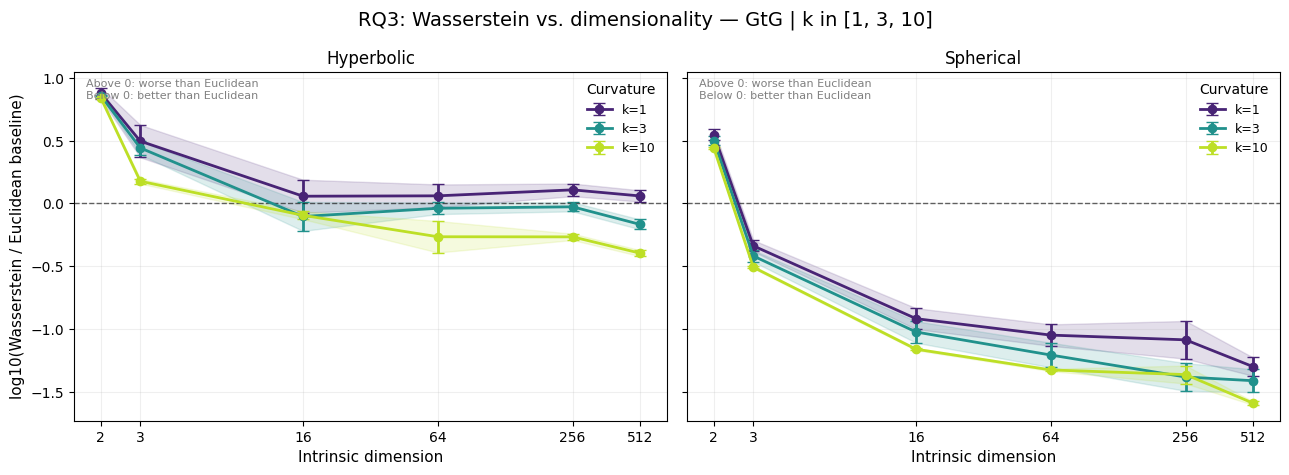

In [99]:
if _df is not None:
    fig, _ = plot_wasserstein_vs_dim(
        _df,
        selected_curvatures=SELECTED_CURVATURES,
        title_suffix=f"GtG | k in {SELECTED_CURVATURES}",
    )
    plt.show()

### Appendix A: Stability diagnostics — NaN rate and vector field norm

Top row: fraction of numerically diverged outputs per (curvature, dim) cell. Bottom row: log₁₀ of mean vector field norm. High values in either indicate instability rather than a genuine geometric effect.

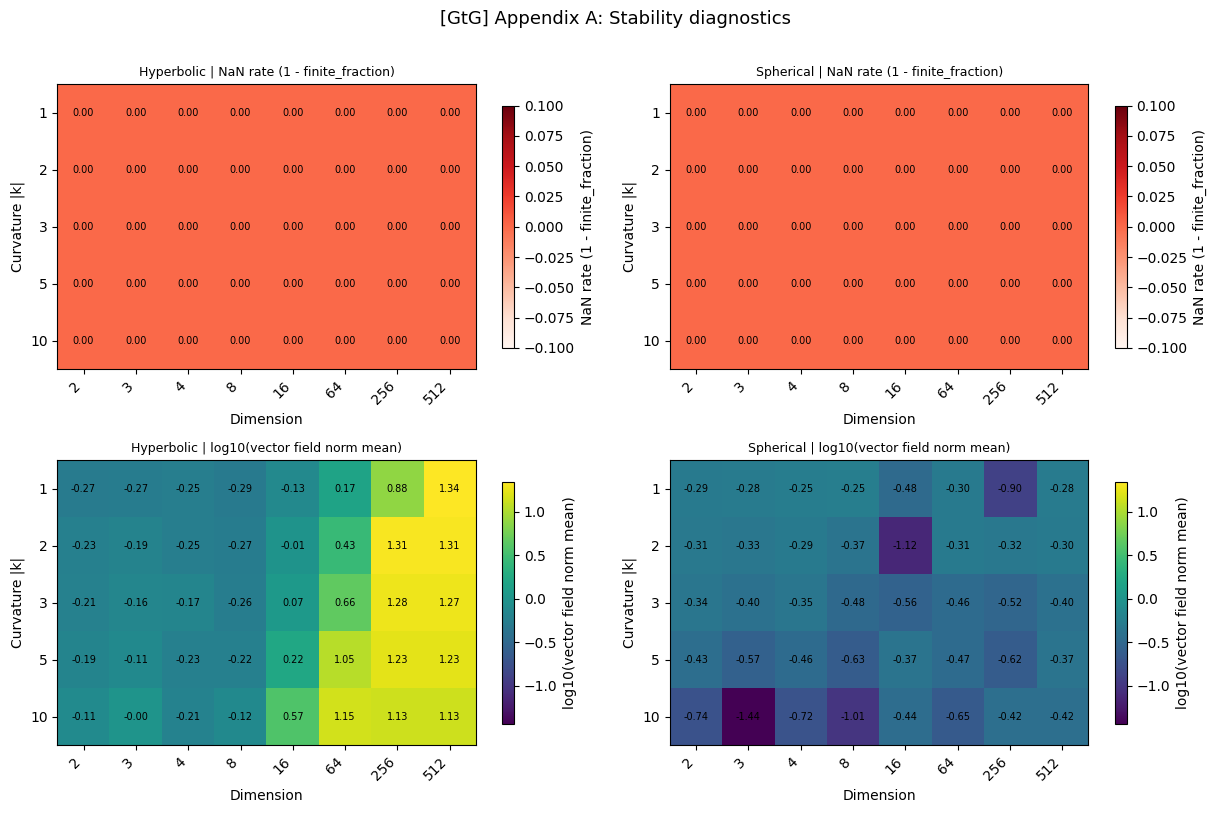

In [58]:
if _df is not None:
    fig, _ = plot_stability_heatmaps(_df, title_prefix="GtG")
    plt.show()

### Appendix B: Training cost — NFE per manifold and dimension

Number of function evaluations (NFE) is the compute proxy. Expect roughly flat values across dimensions; large increases would mean curved geometry adds cost.

In [59]:
if _df is not None:
    _tbl = make_training_time_table(raw["GtG"], _df)
    if _tbl is not None:
        display(_tbl)

,Manifold,Dimension,Mean NFE,SEM,n runs
0,Euclidean,2,43.3,5.1,3
1,Euclidean,3,39.8,2.1,3
2,Euclidean,4,36.0,2.0,3
3,Euclidean,8,36.0,2.0,3
4,Euclidean,16,31.0,5.5,3
5,Euclidean,64,20.0,0.0,3
6,Euclidean,256,20.0,0.0,3
7,Euclidean,512,20.0,0.0,3
8,Hyperbolic,2,45.1,1.7,15
9,Hyperbolic,3,54.7,4.2,15


### Appendix C: Volume-growth gap and Wasserstein vs. dimensionality

Row 1: signed-log VGG gap vs dimension. Row 2: log-relative Wasserstein vs dimension. If the two rows co-move, volume-scaling mismatch mechanistically explains performance degradation.

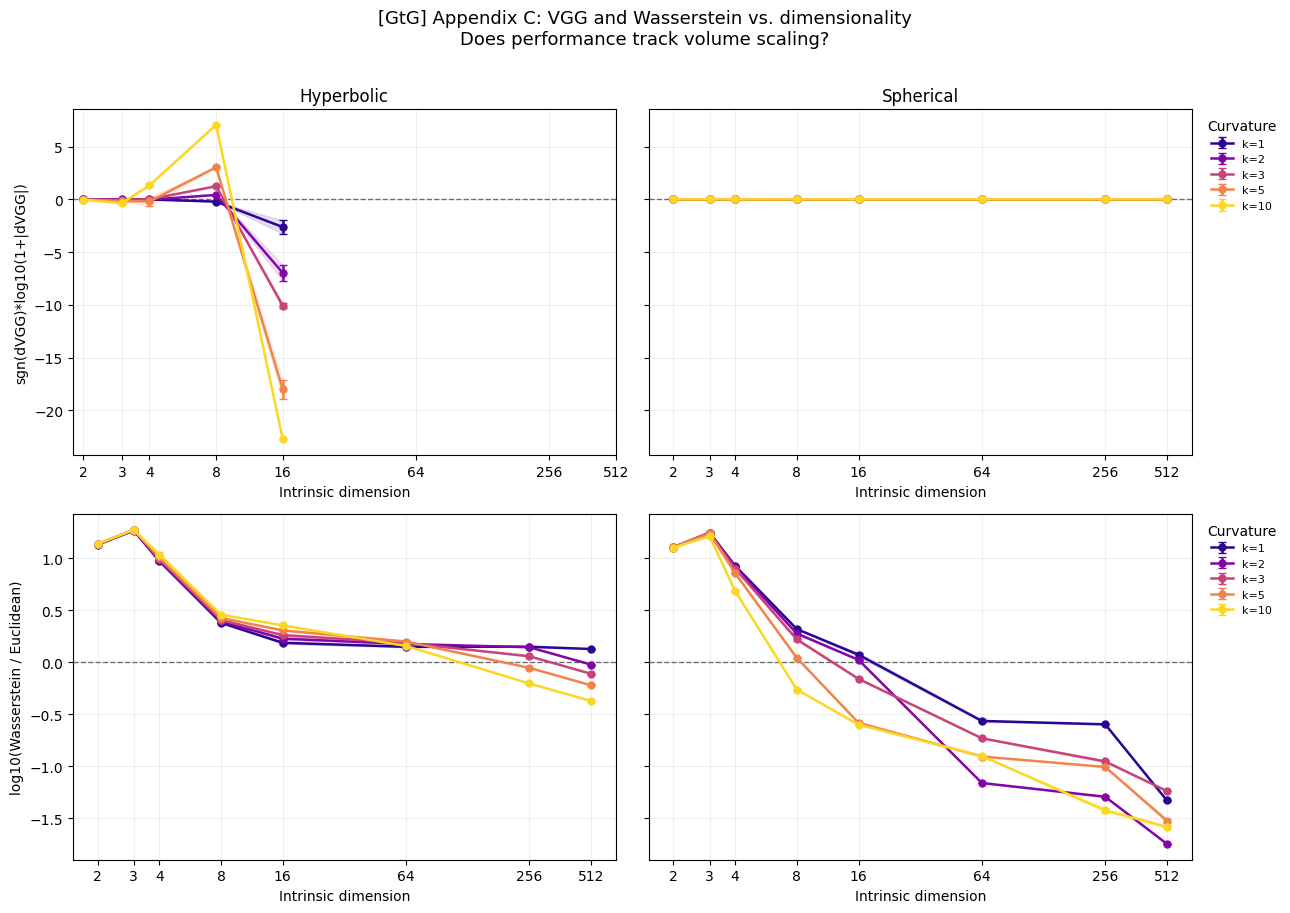

In [60]:
if _df is not None:
    fig, _ = plot_vgg_and_wasserstein_vs_dim(_df, title_prefix="GtG")
    plt.show()

### Appendix D: Spearman ρ — VGG gap vs. Wasserstein by dimension

Statistical test of the VGG-explains-Wasserstein hypothesis. A significant positive ρ at a given dimension means configurations with larger volume-scaling mismatch also have worse Wasserstein at that dimensionality.

In [61]:
if _df is not None:
    _spearman = make_spearman_by_dim_table(_df)
    display(_spearman)

,Dimension,n experiments,Spearman rho,p-value
0,2,10,-0.782,0.008
1,3,10,-0.915,0.000
2,4,10,0.103,0.777
3,8,10,0.685,0.029
4,16,10,-0.758,0.011
5,64,5,0.300,0.624
6,256,5,1.000,0.000
7,512,5,-0.821,0.089
8,All (pooled),65,-0.113,0.372


---
## Section 2 — MoG (Mixture of Gaussians)

### Main text: Wasserstein surface — curvature × dimension

Heatmap of `log10(Wasserstein / Euclidean baseline)`. Red = worse than flat, blue = better. Rows = curvature magnitude, columns = intrinsic dimension.

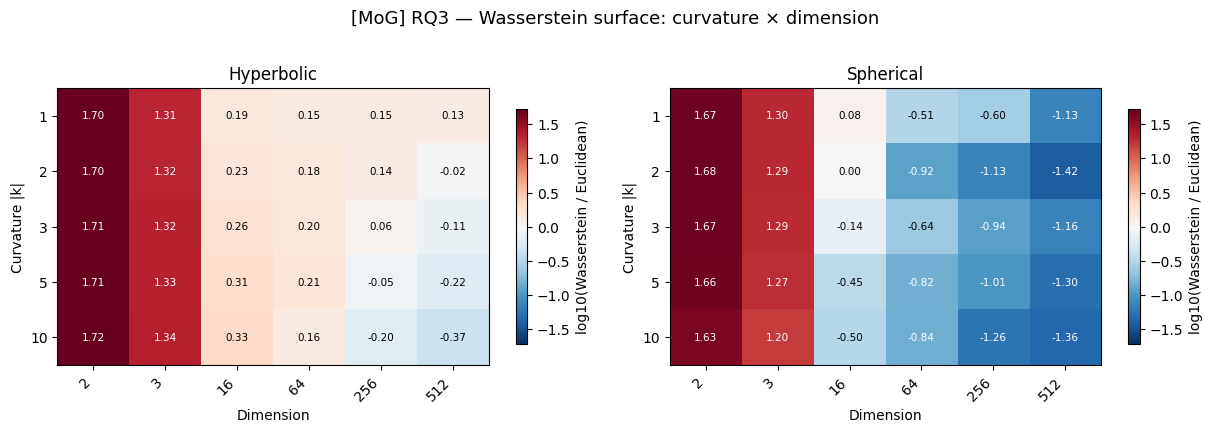

In [62]:
_df = prepared.get("MoG")
if _df is not None:
    _surf = make_curvature_dimension_surface(
        _df, metric_col=PERF_COL,
        value_col_name="log_rel_wasserstein",
        relative_to_euclidean=True, log10_value=True,
    )
    fig, _ = plot_curvature_dimension_heatmaps(
        _surf,
        title="[MoG] RQ3 — Wasserstein surface: curvature × dimension",
        cbar_label="log10(Wasserstein / Euclidean)",
    )
    plt.show()

### Main text: Wasserstein vs. dimensionality — selected curvatures

Line plot for k ∈ {1, 3, 10}. x-axis is intrinsic dimension (log₂ scale). Shaded bands = ±SEM. Dashed line at 0 = parity with Euclidean.

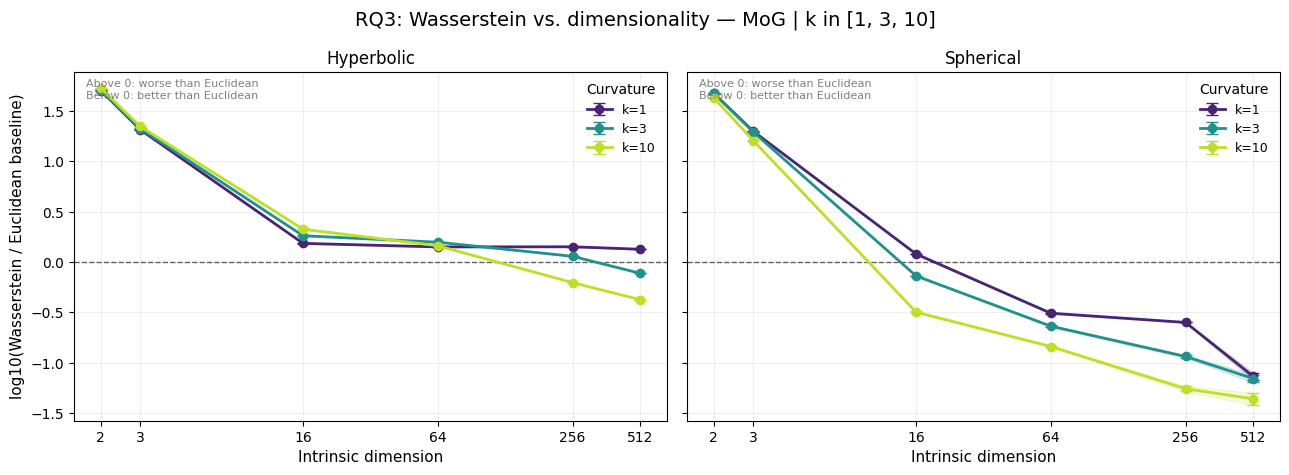

In [63]:
if _df is not None:
    fig, _ = plot_wasserstein_vs_dim(
        _df,
        selected_curvatures=SELECTED_CURVATURES,
        title_suffix=f"MoG | k in {SELECTED_CURVATURES}",
        
    )
    plt.show()

### Appendix A: Stability diagnostics — NaN rate and vector field norm

Top row: fraction of numerically diverged outputs per (curvature, dim) cell. Bottom row: log₁₀ of mean vector field norm. High values in either indicate instability rather than a genuine geometric effect.

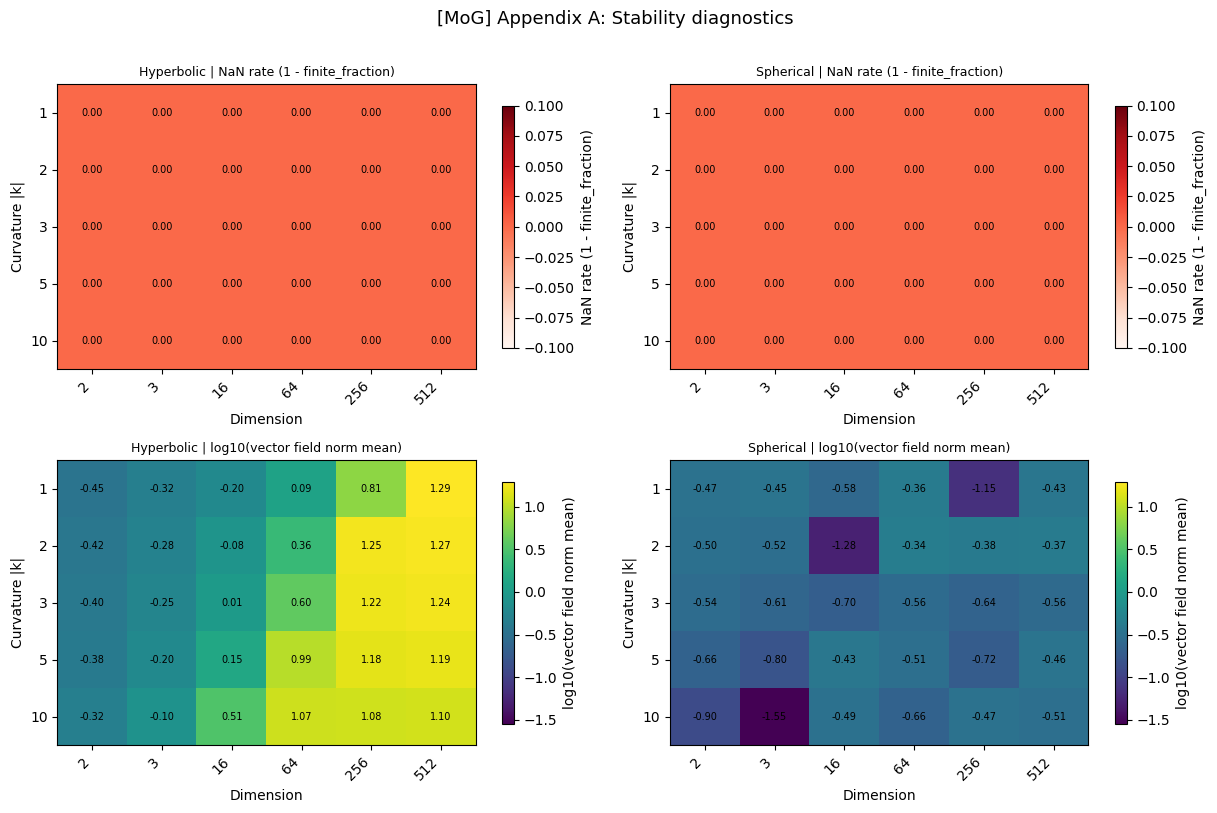

In [64]:
if _df is not None:
    fig, _ = plot_stability_heatmaps(_df, title_prefix="MoG")
    plt.show()

### Appendix B: Training cost — NFE per manifold and dimension

Number of function evaluations (NFE) is the compute proxy. Expect roughly flat values across dimensions; large increases would mean curved geometry adds cost.

In [65]:
if _df is not None:
    _tbl = make_training_time_table(raw["MoG"], _df)
    if _tbl is not None:
        display(_tbl)

,Manifold,Dimension,Mean NFE,SEM,n runs
0,Euclidean,2,55.6,1.5,18
1,Euclidean,3,53.9,1.1,18
2,Euclidean,16,50.1,1.3,18
3,Euclidean,64,27.3,2.7,18
4,Euclidean,256,20.0,0.0,18
5,Euclidean,512,20.0,0.0,18
6,Hyperbolic,2,53.7,0.9,90
7,Hyperbolic,3,60.9,0.7,89
8,Hyperbolic,16,69.4,2.5,87
9,Hyperbolic,64,94.0,5.8,90


### Appendix C: Volume-growth gap and Wasserstein vs. dimensionality

Row 1: signed-log VGG gap vs dimension. Row 2: log-relative Wasserstein vs dimension. If the two rows co-move, volume-scaling mismatch mechanistically explains performance degradation.

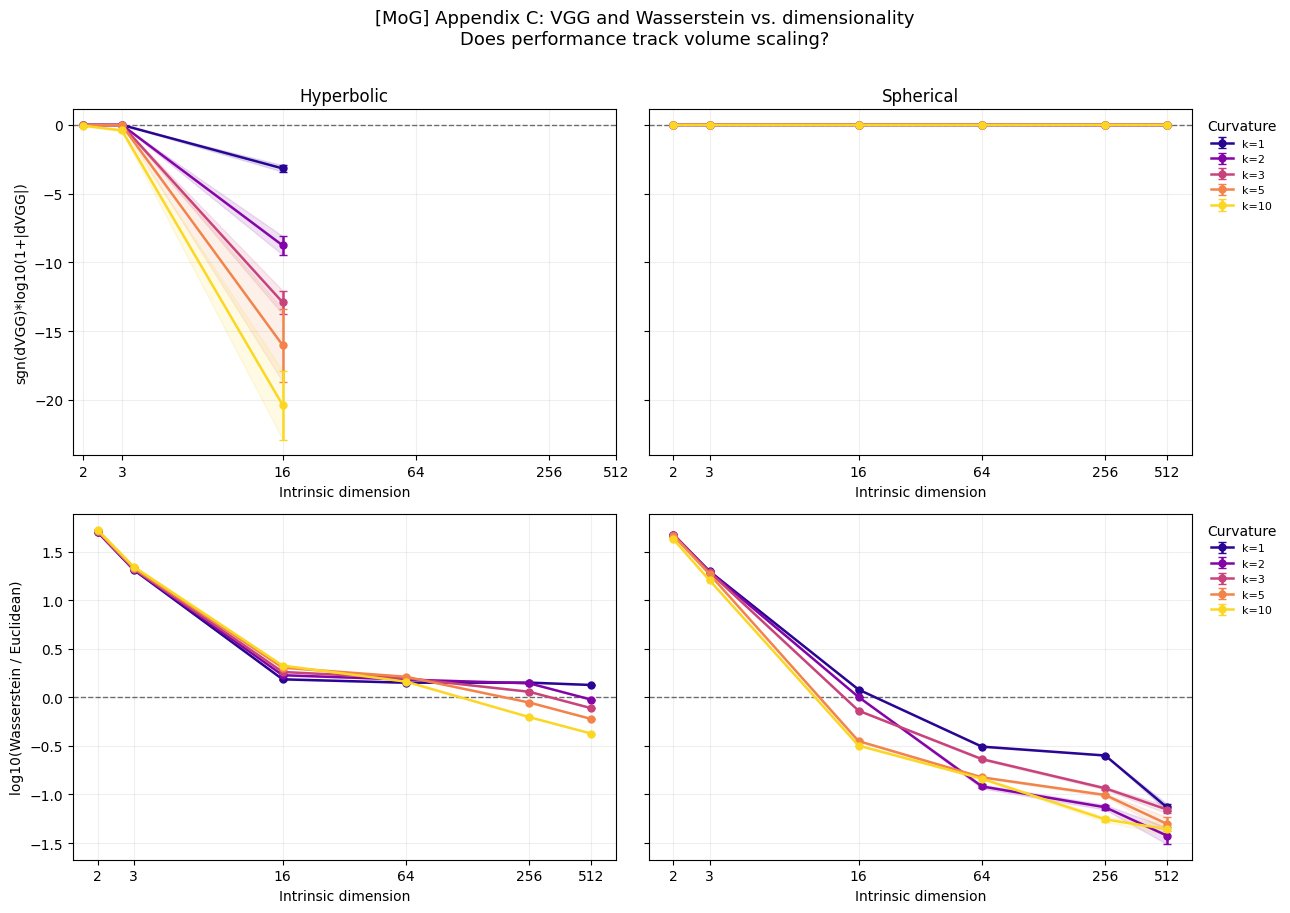

In [66]:
if _df is not None:
    fig, _ = plot_vgg_and_wasserstein_vs_dim(_df, title_prefix="MoG")
    plt.show()

### Appendix D: Spearman ρ — VGG gap vs. Wasserstein by dimension

Statistical test of the VGG-explains-Wasserstein hypothesis. A significant positive ρ at a given dimension means configurations with larger volume-scaling mismatch also have worse Wasserstein at that dimensionality.

In [67]:
if _df is not None:
    _spearman = make_spearman_by_dim_table(_df)
    display(_spearman)

,Dimension,n experiments,Spearman rho,p-value
0,2,10,-0.952,0.000
1,3,10,-0.952,0.000
2,16,10,-0.806,0.005
3,64,5,0.400,0.505
4,256,5,0.600,0.285
5,512,5,-0.821,0.089
6,All (pooled),45,-0.200,0.187


---
## Section 3 — Checkerboard

### Main text: Wasserstein surface — curvature × dimension

Heatmap of `log10(Wasserstein / Euclidean baseline)`. Red = worse than flat, blue = better. Rows = curvature magnitude, columns = intrinsic dimension.

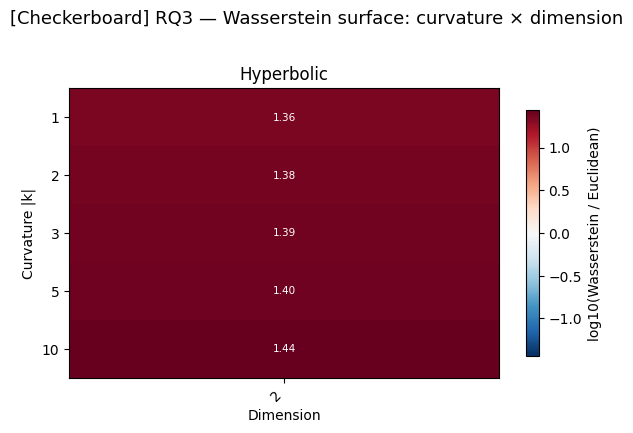

In [68]:
_df = prepared.get("Checkerboard")
if _df is not None:
    _surf = make_curvature_dimension_surface(
        _df, metric_col=PERF_COL,
        value_col_name="log_rel_wasserstein",
        relative_to_euclidean=True, log10_value=True,
    )
    fig, _ = plot_curvature_dimension_heatmaps(
        _surf,
        title="[Checkerboard] RQ3 — Wasserstein surface: curvature × dimension",
        cbar_label="log10(Wasserstein / Euclidean)",
    )
    plt.show()

### Main text: Wasserstein vs. dimensionality — selected curvatures

Line plot for k ∈ {1, 3, 10}. x-axis is intrinsic dimension (log₂ scale). Shaded bands = ±SEM. Dashed line at 0 = parity with Euclidean.

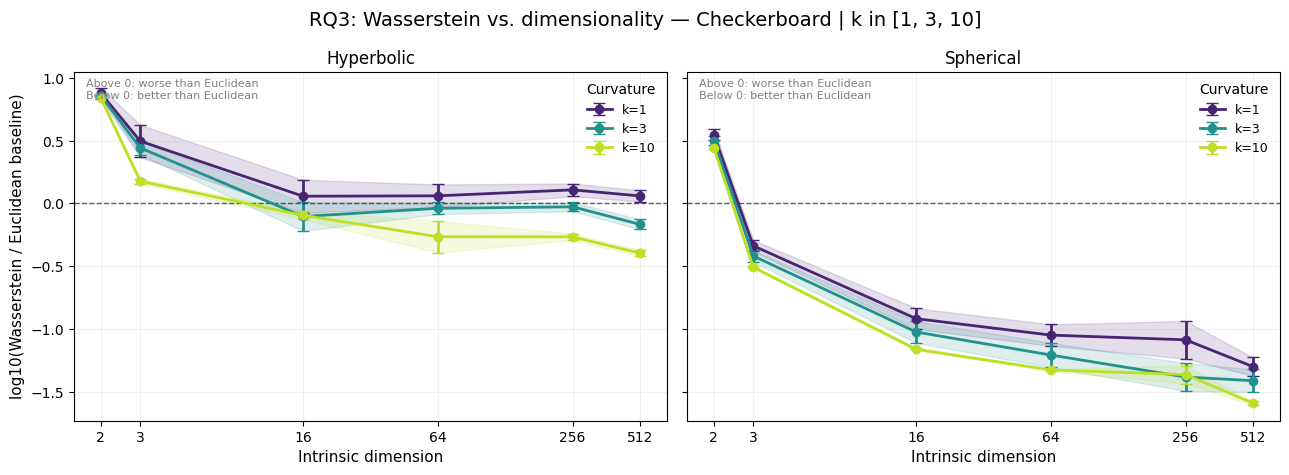

In [100]:
if _df is not None:
    fig, _ = plot_wasserstein_vs_dim(
        _df,
        selected_curvatures=SELECTED_CURVATURES,
        title_suffix=f"Checkerboard | k in {SELECTED_CURVATURES}",
    )
    plt.show()

### Appendix A: Stability diagnostics — NaN rate and vector field norm

Top row: fraction of numerically diverged outputs per (curvature, dim) cell. Bottom row: log₁₀ of mean vector field norm. High values in either indicate instability rather than a genuine geometric effect.

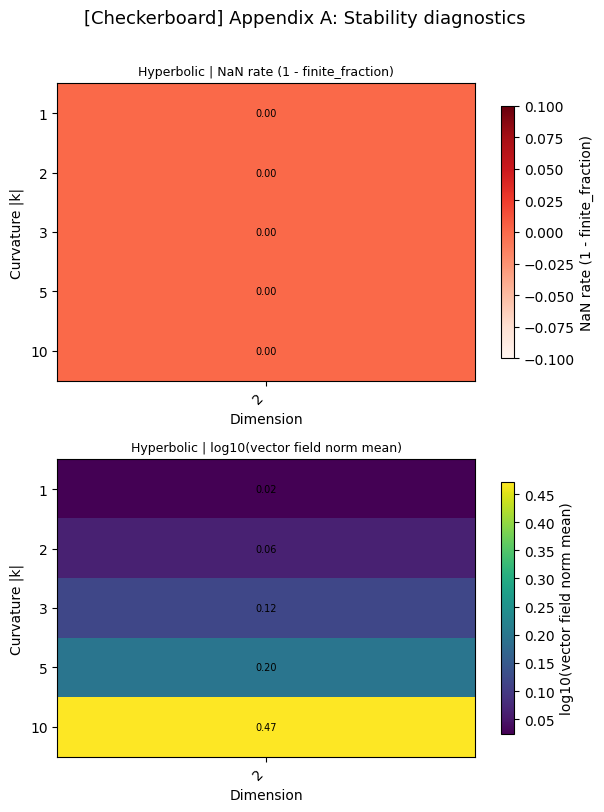

In [70]:
if _df is not None:
    fig, _ = plot_stability_heatmaps(_df, title_prefix="Checkerboard")
    plt.show()

### Appendix B: Training cost — NFE per manifold and dimension

Number of function evaluations (NFE) is the compute proxy. Expect roughly flat values across dimensions; large increases would mean curved geometry adds cost.

In [71]:
if _df is not None:
    _tbl = make_training_time_table(raw["Checkerboard"], _df)
    if _tbl is not None:
        display(_tbl)

,Manifold,Dimension,Mean NFE,SEM,n runs
0,Euclidean,2,95.9,5.2,10
1,Hyperbolic,2,87.4,9.1,45


### Appendix C: Volume-growth gap and Wasserstein vs. dimensionality

Row 1: signed-log VGG gap vs dimension. Row 2: log-relative Wasserstein vs dimension. If the two rows co-move, volume-scaling mismatch mechanistically explains performance degradation.

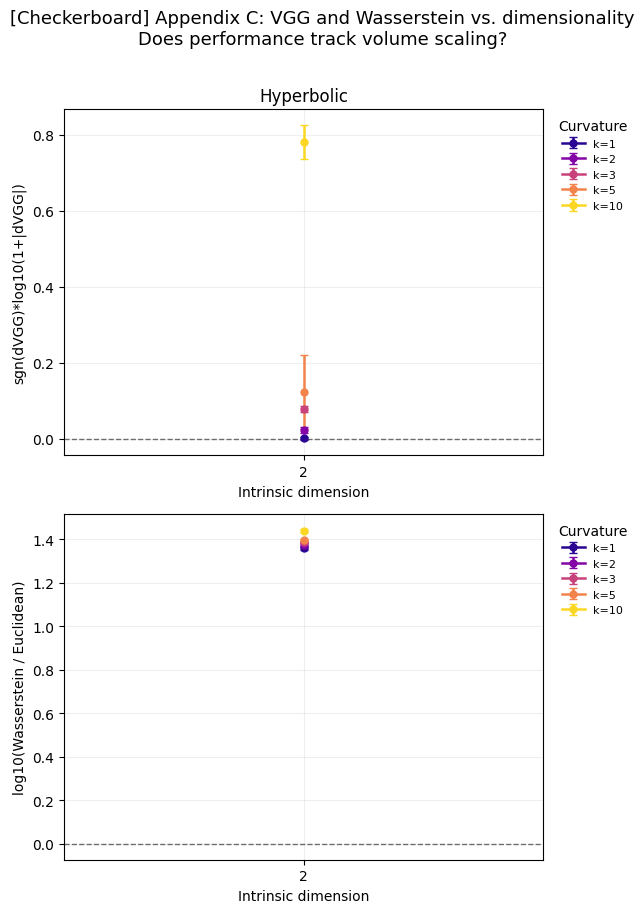

In [72]:
if _df is not None:
    fig, _ = plot_vgg_and_wasserstein_vs_dim(_df, title_prefix="Checkerboard")
    plt.show()

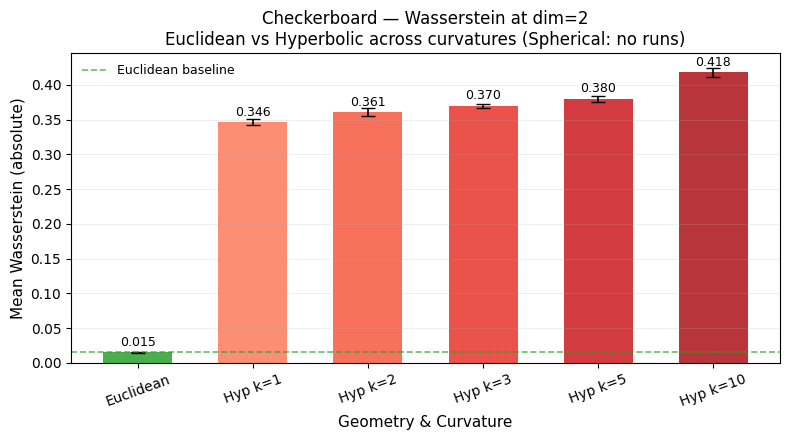

In [101]:
# ---------------------------------------------------------------------------
# Checkerboard — Absolute Wasserstein per geometry and curvature at dim=2
# ---------------------------------------------------------------------------

df_cb   = prepared.get("Checkerboard")

if df_cb is not None:
    df_plot = df_cb.replace([np.inf, -np.inf], np.nan)
    df_dim2 = df_plot[df_plot["compare_dim"].eq(2)]

    rows = []

    # Euclidean (no curvature)
    euc_val = df_dim2[df_dim2[MANIFOLD_COL].eq(EUCLIDEAN_NAME)][PERF_COL]
    rows.append({
        "label": "Euclidean",
        "mean":  euc_val.mean(),
        "sem":   error_value(euc_val, ERROR_BAR),
        "color": "#2CA02C",
    })

    # Hyperbolic per curvature
    curvs = ordered_curvatures(df_dim2[CURV_COL].dropna().unique(), order=CURVATURE_ORDER)
    red_shades = plt.cm.Reds(np.linspace(0.35, 0.85, len(curvs)))
    for curv, color in zip(curvs, red_shades):
        sub = df_dim2[
            df_dim2[MANIFOLD_COL].eq(POINCARE_NAME) &
            df_dim2[CURV_COL].eq(curv)
        ][PERF_COL]
        if sub.empty:
            continue
        rows.append({
            "label": f"Hyp k={nice_curv_label(curv)}",
            "mean":  sub.mean(),
            "sem":   error_value(sub, ERROR_BAR),
            "color": color,
        })

    labels = [r["label"] for r in rows]
    means  = [r["mean"]  for r in rows]
    sems   = [r["sem"]   for r in rows]
    colors = [r["color"] for r in rows]

    fig, ax = plt.subplots(figsize=(8, 4.5))
    bars = ax.bar(labels, means, yerr=sems, color=colors, alpha=0.85,
                  capsize=5, width=0.6, error_kw={"linewidth": 1.2})

    # Annotate value on top of each bar
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{mean:.3f}",
                ha="center", va="bottom", fontsize=9)

    ax.set_ylabel("Mean Wasserstein (absolute)", fontsize=11)
    ax.set_xlabel("Geometry & Curvature", fontsize=11)
    ax.set_title("Checkerboard — Wasserstein at dim=2\n"
                 "Euclidean vs Hyperbolic across curvatures (Spherical: no runs)",
                 fontsize=12)
    ax.tick_params(axis="x", rotation=20)
    ax.grid(axis="y", alpha=0.2)

    # Reference line at Euclidean level
    ax.axhline(means[0], color="#2CA02C", linestyle="--",
               linewidth=1.2, alpha=0.7, label="Euclidean baseline")
    ax.legend(frameon=False, fontsize=9)

    fig.tight_layout()
    plt.show()
else:
    print("Checkerboard not found in prepared datasets.")

### Appendix D: Spearman ρ — VGG gap vs. Wasserstein by dimension

Statistical test of the VGG-explains-Wasserstein hypothesis. A significant positive ρ at a given dimension means configurations with larger volume-scaling mismatch also have worse Wasserstein at that dimensionality.

In [73]:
if _df is not None:
    _spearman = make_spearman_by_dim_table(_df)
    display(_spearman)

,Dimension,n experiments,Spearman rho,p-value
0,2,5,1.0,0.000
1,All (pooled),5,1.0,0.000


---
## Section 4 — Gaussian Ring

### Main text: Wasserstein surface — curvature × dimension

Heatmap of `log10(Wasserstein / Euclidean baseline)`. Red = worse than flat, blue = better. Rows = curvature magnitude, columns = intrinsic dimension.

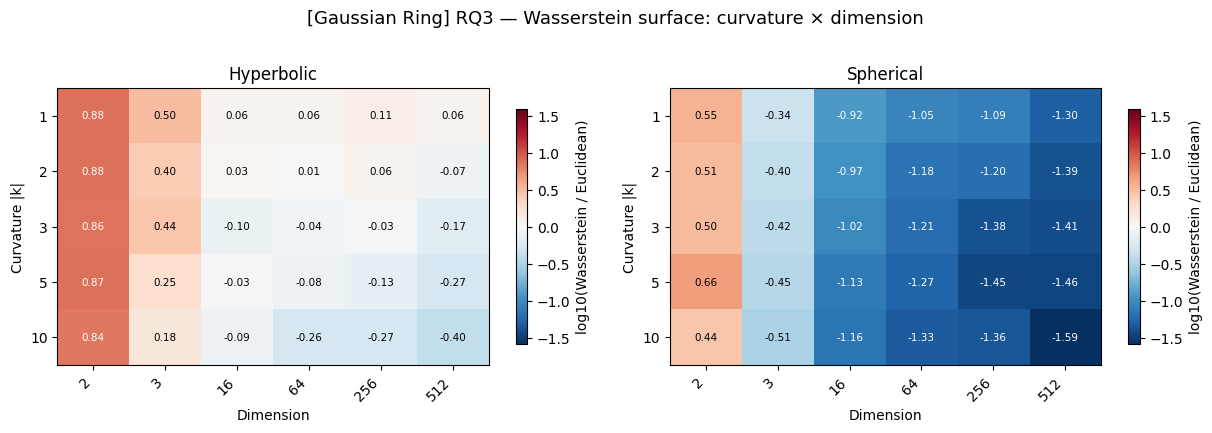

In [74]:
_df = prepared.get("Gaussian Ring")
if _df is not None:
    _surf = make_curvature_dimension_surface(
        _df, metric_col=PERF_COL,
        value_col_name="log_rel_wasserstein",
        relative_to_euclidean=True, log10_value=True,
    )
    fig, _ = plot_curvature_dimension_heatmaps(
        _surf,
        title="[Gaussian Ring] RQ3 — Wasserstein surface: curvature × dimension",
        cbar_label="log10(Wasserstein / Euclidean)",
    )
    plt.show()

### Main text: Wasserstein vs. dimensionality — selected curvatures

Line plot for k ∈ {1, 3, 10}. x-axis is intrinsic dimension (log₂ scale). Shaded bands = ±SEM. Dashed line at 0 = parity with Euclidean.

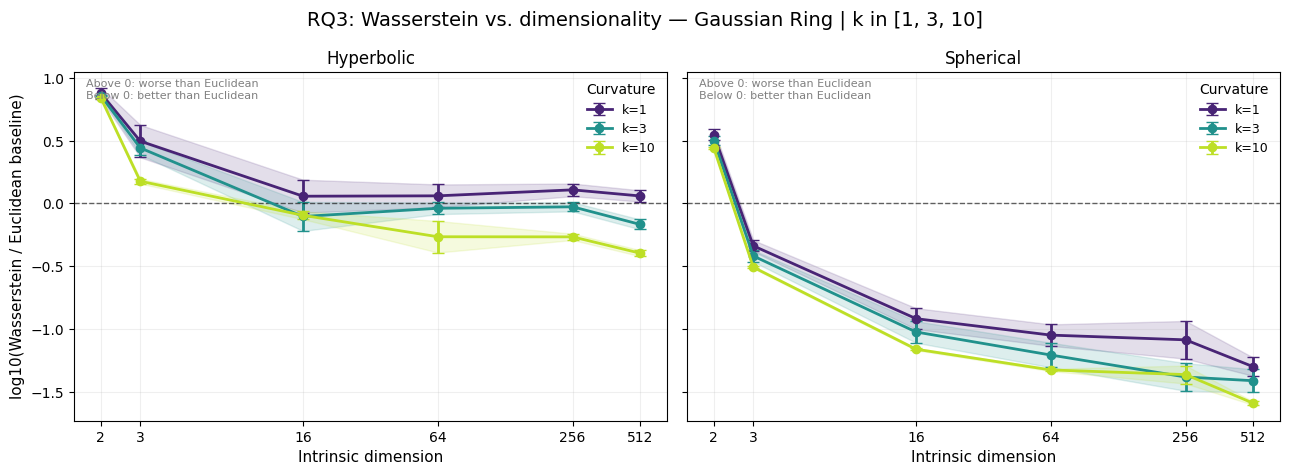

In [98]:
if _df is not None:
    fig, _ = plot_wasserstein_vs_dim(
        _df,
        selected_curvatures=SELECTED_CURVATURES,
        title_suffix=f"Gaussian Ring | k in {SELECTED_CURVATURES}",
    )
    plt.show()

### Appendix A: Stability diagnostics — NaN rate and vector field norm

Top row: fraction of numerically diverged outputs per (curvature, dim) cell. Bottom row: log₁₀ of mean vector field norm. High values in either indicate instability rather than a genuine geometric effect.

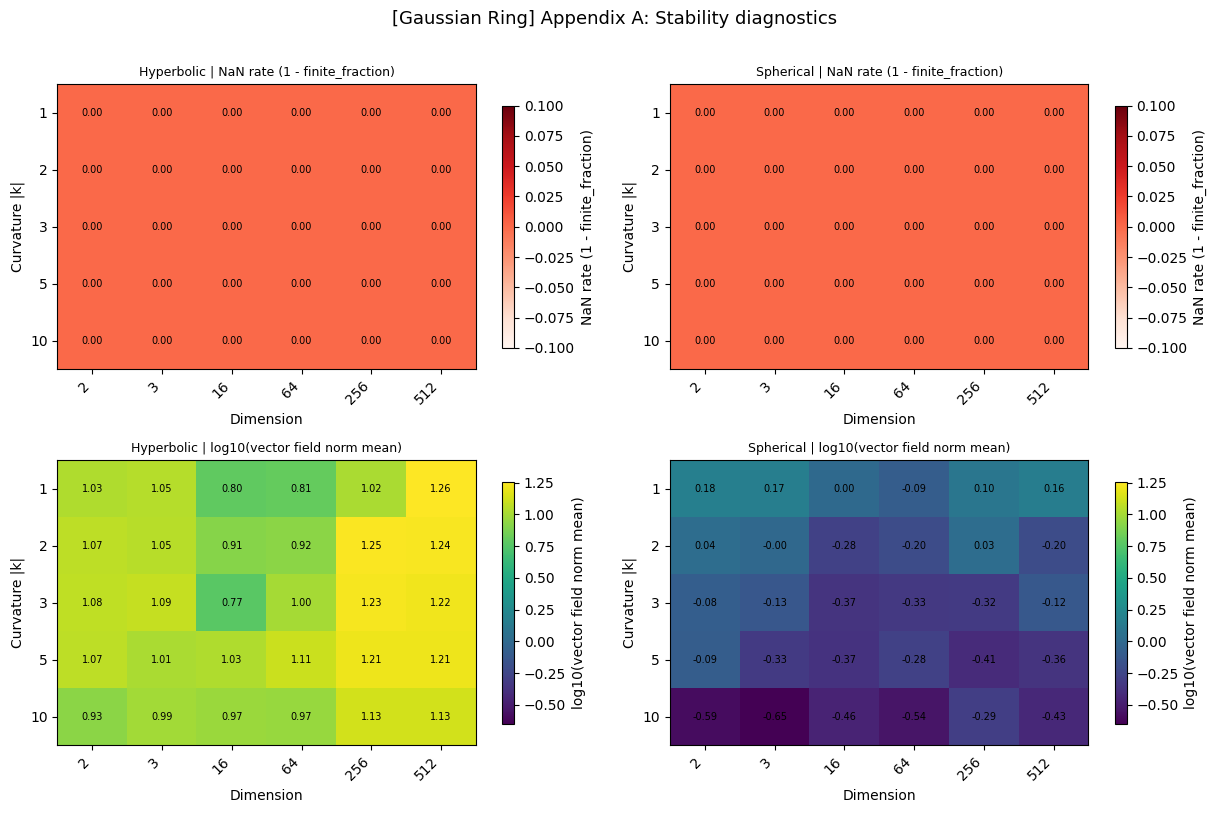

In [76]:
if _df is not None:
    fig, _ = plot_stability_heatmaps(_df, title_prefix="Gaussian Ring")
    plt.show()

### Appendix B: Training cost — NFE per manifold and dimension

Number of function evaluations (NFE) is the compute proxy. Expect roughly flat values across dimensions; large increases would mean curved geometry adds cost.

In [77]:
if _df is not None:
    _tbl = make_training_time_table(raw["Gaussian Ring"], _df)
    if _tbl is not None:
        display(_tbl)

,Manifold,Dimension,Mean NFE,SEM,n runs
0,Euclidean,2,89.4,11.5,9
1,Euclidean,3,81.3,15.0,8
2,Euclidean,16,55.9,4.0,9
3,Euclidean,64,38.7,2.1,9
4,Euclidean,256,20.0,0.0,9
5,Euclidean,512,24.7,4.7,9
6,Hyperbolic,2,167.0,22.5,46
7,Hyperbolic,3,165.4,13.7,42
8,Hyperbolic,16,105.1,6.9,42
9,Hyperbolic,64,90.4,4.5,44


### Appendix C: Volume-growth gap and Wasserstein vs. dimensionality

Row 1: signed-log VGG gap vs dimension. Row 2: log-relative Wasserstein vs dimension. If the two rows co-move, volume-scaling mismatch mechanistically explains performance degradation.

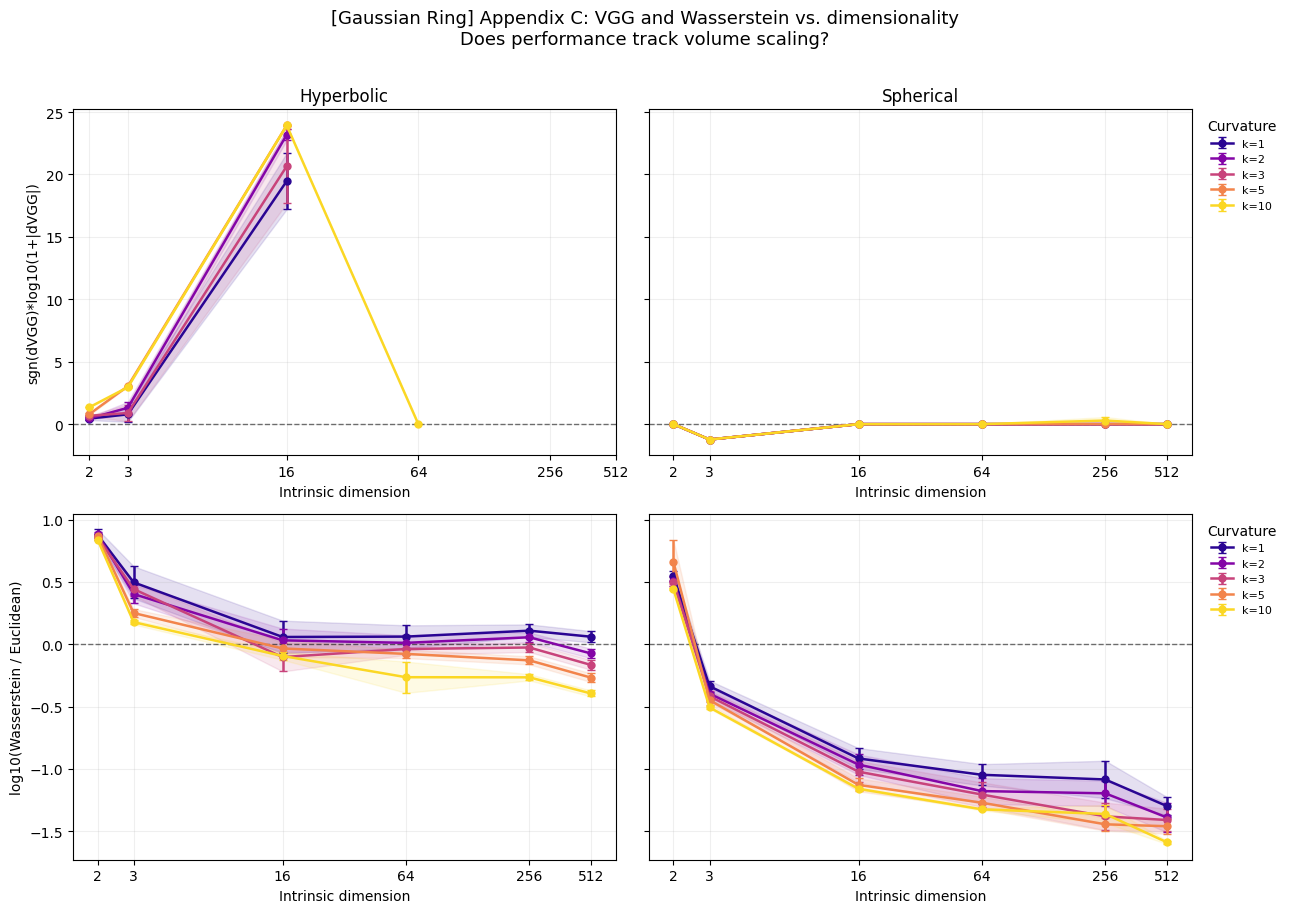

In [78]:
if _df is not None:
    fig, _ = plot_vgg_and_wasserstein_vs_dim(_df, title_prefix="Gaussian Ring")
    plt.show()

### Appendix D: Spearman ρ — VGG gap vs. Wasserstein by dimension

Statistical test of the VGG-explains-Wasserstein hypothesis. A significant positive ρ at a given dimension means configurations with larger volume-scaling mismatch also have worse Wasserstein at that dimensionality.

In [79]:
if _df is not None:
    _spearman = make_spearman_by_dim_table(_df)
    display(_spearman)

,Dimension,n experiments,Spearman rho,p-value
0,2,10,0.648,0.043
1,3,10,0.600,0.067
2,16,10,0.830,0.003
3,64,6,0.657,0.156
4,256,5,0.200,0.747
5,512,5,-0.707,0.182
6,All (pooled),46,0.388,0.008


---
## Section 5 — Cross-dataset comparison

### 5.1 Wasserstein surface heatmaps — side by side

Same colormap scale is applied across all four heatmaps so intensities are directly comparable across datasets.

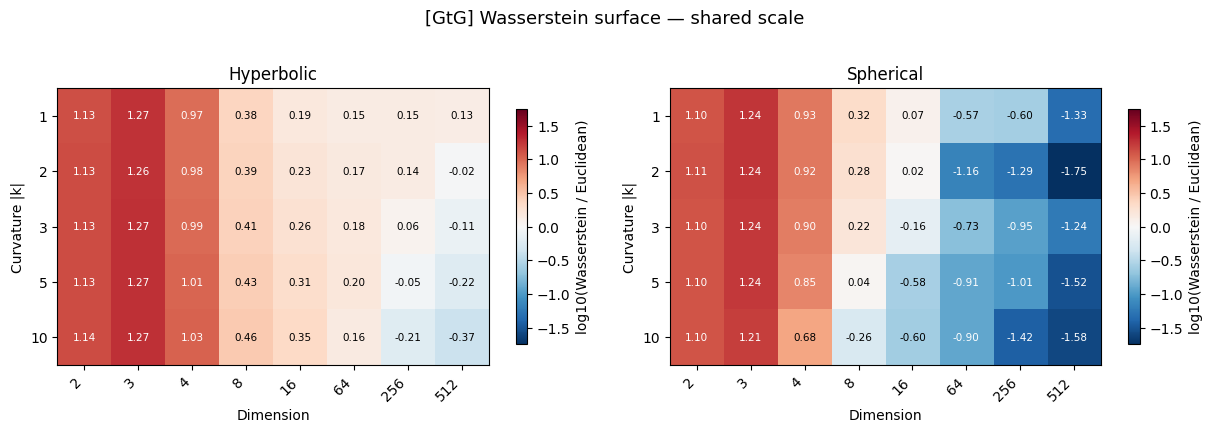

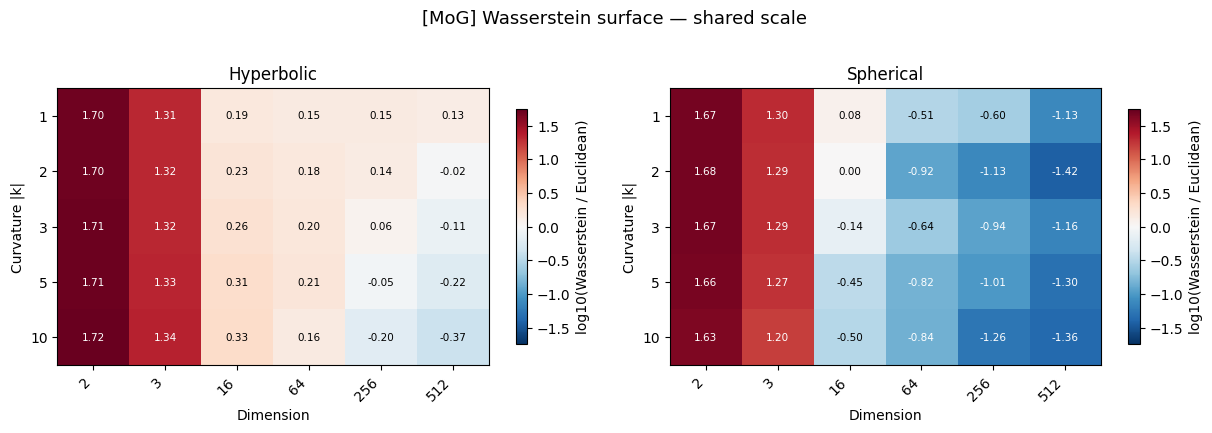

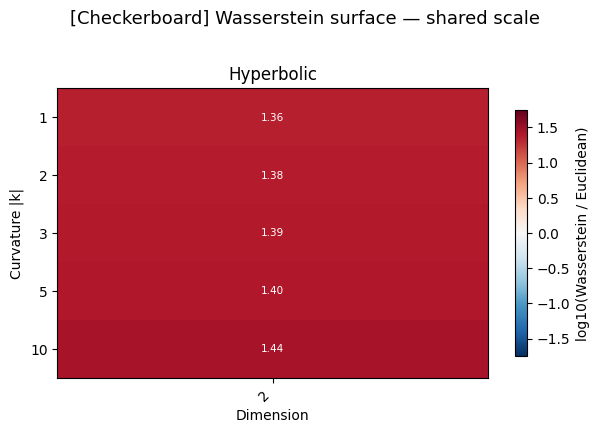

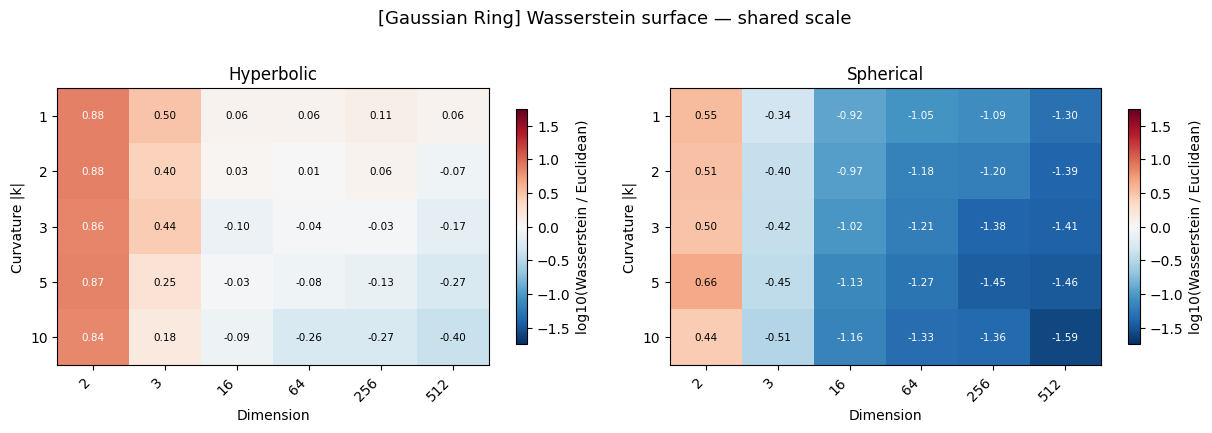

In [80]:
_vmaxes = []
_surfaces = {}
for name, df in prepared.items():
    s = make_curvature_dimension_surface(
        df, metric_col=PERF_COL,
        value_col_name="log_rel_wasserstein",
        relative_to_euclidean=True, log10_value=True,
    )
    _surfaces[name] = s
    v = s["mean"].replace([np.inf, -np.inf], np.nan)
    _vmaxes.append(max(abs(np.nanmin(v)), abs(np.nanmax(v))))

_shared_vmax = max(_vmaxes)

for name, s in _surfaces.items():
    manifolds_in = [m for m in [POINCARE_NAME, SPHERE_NAME]
                    if m in s[MANIFOLD_COL].unique()]
    fig, axes = plt.subplots(1, len(manifolds_in),
                             figsize=(6.2 * len(manifolds_in), 4.2), squeeze=False)
    axes = axes[0]
    for ax, manifold in zip(axes, manifolds_in):
        sub  = s[s[MANIFOLD_COL].eq(manifold)].copy()
        dims = ordered_values_numeric(sub["compare_dim"])
        curvs = ordered_values_numeric(sub[CURV_COL], use_abs=True)
        pivot = (
            sub.pivot_table(index=CURV_COL, columns="compare_dim",
                            values="mean", aggfunc="mean")
            .reindex(index=curvs, columns=dims)
        )
        im = ax.imshow(pivot.values, aspect="auto", cmap="RdBu_r",
                       vmin=-_shared_vmax, vmax=_shared_vmax,
                       interpolation="nearest")
        ax.set_xticks(range(len(dims)))
        ax.set_xticklabels([nice_dim_label(d) for d in dims], rotation=45, ha="right")
        ax.set_yticks(range(len(curvs)))
        ax.set_yticklabels([nice_curv_label(c) for c in curvs])
        ax.set_xlabel("Dimension"); ax.set_ylabel("Curvature |k|")
        ax.set_title(display_manifold_name(manifold))
        for ri in range(pivot.shape[0]):
            for ci in range(pivot.shape[1]):
                val = pivot.iloc[ri, ci]
                if not np.isnan(val):
                    tc = "white" if abs(val) > 0.45 * _shared_vmax else "black"
                    ax.text(ci, ri, f"{val:.2f}", ha="center", va="center",
                            fontsize=7.5, color=tc)
        plt.colorbar(im, ax=ax, label="log10(Wasserstein / Euclidean)", shrink=0.85)
    fig.suptitle(f"[{name}] Wasserstein surface — shared scale", fontsize=13, y=1.02)
    fig.tight_layout()
    plt.show()

### 5.2 Wasserstein vs. dimensionality — all datasets overlaid

One panel per manifold. Each dataset is one line, averaged over all curvatures. Shows whether the dimension-induced degradation is universal or dataset-specific.

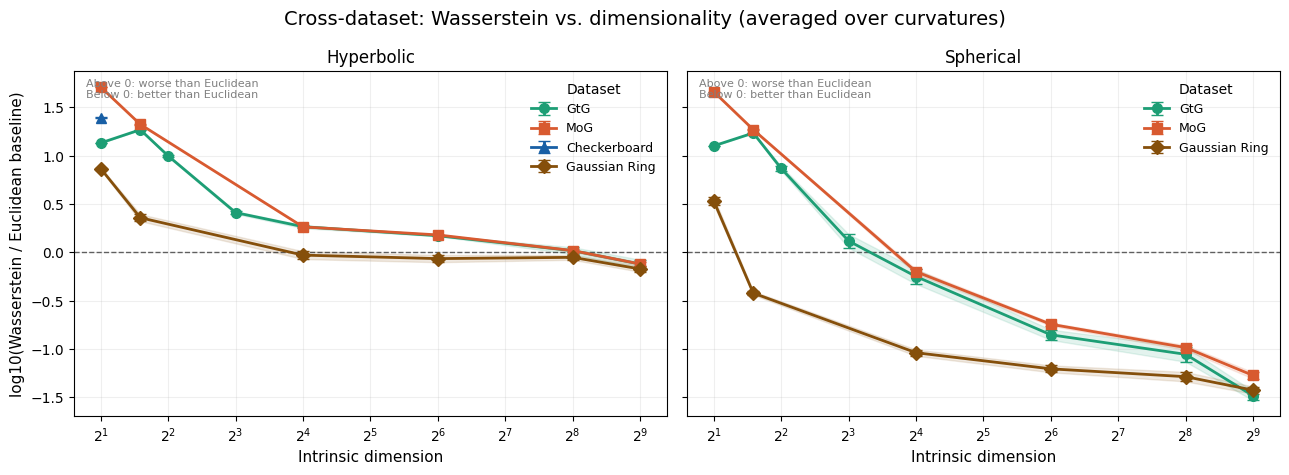

In [81]:
manifolds_to_compare = [POINCARE_NAME, SPHERE_NAME]
fig, axes = plt.subplots(1, len(manifolds_to_compare),
                         figsize=(6.5 * len(manifolds_to_compare), 4.8),
                         sharey=True)
if len(manifolds_to_compare) == 1:
    axes = [axes]

for ax, manifold in zip(axes, manifolds_to_compare):
    for (name, df), color, marker in zip(
        prepared.items(), DATASET_COLORS, DATASET_MARKERS
    ):
        sub = (
            df[df[MANIFOLD_COL].eq(manifold)]
            .replace([np.inf, -np.inf], np.nan)
            .groupby("compare_dim", as_index=False)
            .agg(
                y_mean=("log_rel_perf", "mean"),
                y_sem=("log_rel_perf",
                       lambda x: error_value(x, ERROR_BAR)),
            )
            .sort_values("compare_dim")
        )
        if sub.empty:
            continue
        d, ym, ys = sub["compare_dim"].values, sub["y_mean"].values, sub["y_sem"].values
        ax.fill_between(d, ym - ys, ym + ys, alpha=0.12, color=color)
        ax.errorbar(d, ym, yerr=ys, fmt=f"{marker}-", color=color,
                    markersize=7, capsize=4, linewidth=2, label=name)
    ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.6)
    ax.set_xscale("log", base=2)
    ax.set_xlabel("Intrinsic dimension", fontsize=11)
    ax.set_title(display_manifold_name(manifold), fontsize=12)
    ax.legend(frameon=False, title="Dataset", fontsize=9)
    ax.grid(alpha=0.2)
    ax.text(0.02, 0.98, "Above 0: worse than Euclidean\nBelow 0: better than Euclidean",
            transform=ax.transAxes, fontsize=8, va="top", color="grey")

axes[0].set_ylabel("log10(Wasserstein / Euclidean baseline)", fontsize=11)
fig.suptitle("Cross-dataset: Wasserstein vs. dimensionality (averaged over curvatures)",
             fontsize=14)
fig.tight_layout()
plt.show()

### 5.3 Wasserstein vs. dimensionality — selected curvatures, all datasets overlaid

Same as 5.2 but filtered to selected curvatures only, matching the main-text figure style from individual sections.

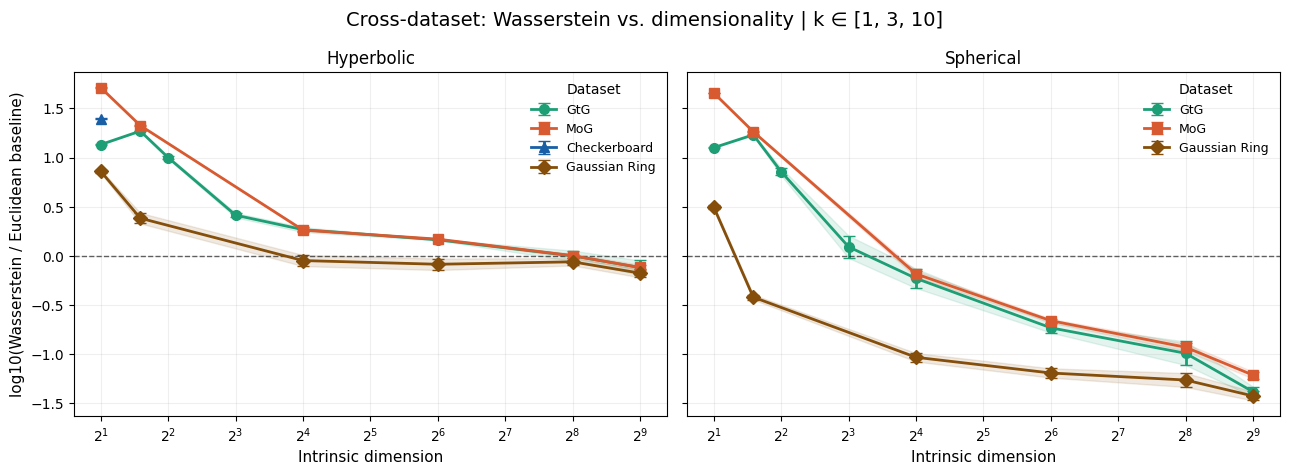

In [82]:
fig, axes = plt.subplots(1, len(manifolds_to_compare),
                         figsize=(6.5 * len(manifolds_to_compare), 4.8),
                         sharey=True)
if len(manifolds_to_compare) == 1:
    axes = [axes]

for ax, manifold in zip(axes, manifolds_to_compare):
    for (name, df), color, marker in zip(
        prepared.items(), DATASET_COLORS, DATASET_MARKERS
    ):
        sub_df = (
            df[df[MANIFOLD_COL].eq(manifold) & df[CURV_COL].isin(SELECTED_CURVATURES)]
            .replace([np.inf, -np.inf], np.nan)
            .groupby("compare_dim", as_index=False)
            .agg(
                y_mean=("log_rel_perf", "mean"),
                y_sem=("log_rel_perf", lambda x: error_value(x, ERROR_BAR)),
            )
            .sort_values("compare_dim")
        )
        if sub_df.empty:
            continue
        d, ym, ys = sub_df["compare_dim"].values, sub_df["y_mean"].values, sub_df["y_sem"].values
        ax.fill_between(d, ym - ys, ym + ys, alpha=0.12, color=color)
        ax.errorbar(d, ym, yerr=ys, fmt=f"{marker}-", color=color,
                    markersize=7, capsize=4, linewidth=2, label=name)
    ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.6)
    ax.set_xscale("log", base=2)
    ax.set_xlabel("Intrinsic dimension", fontsize=11)
    ax.set_title(display_manifold_name(manifold), fontsize=12)
    ax.legend(frameon=False, title="Dataset", fontsize=9)
    ax.grid(alpha=0.2)

axes[0].set_ylabel("log10(Wasserstein / Euclidean baseline)", fontsize=11)
fig.suptitle(f"Cross-dataset: Wasserstein vs. dimensionality | k ∈ {SELECTED_CURVATURES}",
             fontsize=14)
fig.tight_layout()
plt.show()

### 5.4 Pooled Spearman ρ — VGG gap predicts Wasserstein?

One bar per dataset. Green = positive correlation (VGG gap and Wasserstein degrade together, supporting VGG as a mechanism). Significance stars from pooled Spearman test across all dimensions and curvatures.

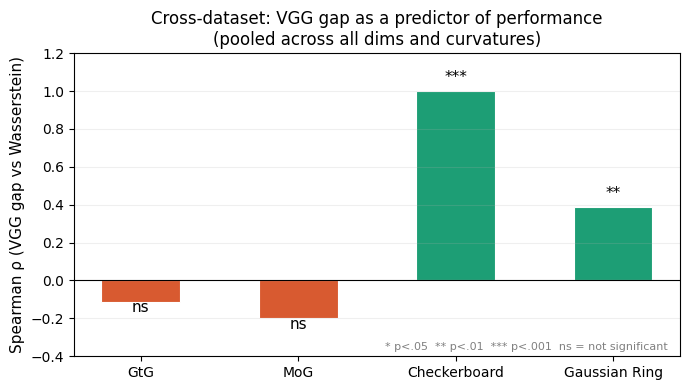

In [83]:
_spearman_all = {}
for name, df in prepared.items():
    _spearman_all[name] = make_spearman_by_dim_table(df)

rho_summary = {}
for name, tbl in _spearman_all.items():
    row = tbl[tbl["Dimension"] == "All (pooled)"]
    if not row.empty:
        try:
            rho_summary[name] = (float(row["Spearman rho"].values[0]),
                                 float(row["p-value"].values[0]))
        except (ValueError, TypeError):
            rho_summary[name] = (np.nan, np.nan)

names  = list(rho_summary.keys())
rhos   = [rho_summary[n][0] for n in names]
pvals  = [rho_summary[n][1] for n in names]
colors = ["#1D9E75" if r > 0 else "#D85A30" for r in rhos]
sigs   = ["***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
          for p in pvals]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(names, rhos, color=colors, width=0.5, edgecolor="white", linewidth=0.8)
for bar, sig in zip(bars, sigs):
    y      = bar.get_height()
    offset = 0.03 if y >= 0 else -0.07
    ax.text(bar.get_x() + bar.get_width() / 2, y + offset, sig,
            ha="center", va="bottom", fontsize=11)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Spearman ρ (VGG gap vs Wasserstein)", fontsize=11)
ax.set_title("Cross-dataset: VGG gap as a predictor of performance\n(pooled across all dims and curvatures)", fontsize=12)
ax.set_ylim(min(min(rhos) - 0.2, -0.15), max(max(rhos) + 0.2, 0.25))
ax.grid(axis="y", alpha=0.2)
ax.text(0.98, 0.02, "* p<.05  ** p<.01  *** p<.001  ns = not significant",
        transform=ax.transAxes, fontsize=8, ha="right", color="grey")
fig.tight_layout()
plt.show()

### 5.5 Spearman ρ by dimension — all datasets

One table per dataset showing per-dimension Spearman ρ. Lets you see whether the VGG–Wasserstein link strengthens, weakens, or breaks at high dimensions.

In [84]:
for name, tbl in _spearman_all.items():
    print(f"\n{'='*55}\n  {name}\n{'='*55}")
    display(tbl)


  GtG


,Dimension,n experiments,Spearman rho,p-value
0,2,10,-0.782,0.008
1,3,10,-0.915,0.000
2,4,10,0.103,0.777
3,8,10,0.685,0.029
4,16,10,-0.758,0.011
5,64,5,0.300,0.624
6,256,5,1.000,0.000
7,512,5,-0.821,0.089
8,All (pooled),65,-0.113,0.372



  MoG


,Dimension,n experiments,Spearman rho,p-value
0,2,10,-0.952,0.000
1,3,10,-0.952,0.000
2,16,10,-0.806,0.005
3,64,5,0.400,0.505
4,256,5,0.600,0.285
5,512,5,-0.821,0.089
6,All (pooled),45,-0.200,0.187



  Checkerboard


,Dimension,n experiments,Spearman rho,p-value
0,2,5,1.0,0.000
1,All (pooled),5,1.0,0.000



  Gaussian Ring


,Dimension,n experiments,Spearman rho,p-value
0,2,10,0.648,0.043
1,3,10,0.600,0.067
2,16,10,0.830,0.003
3,64,6,0.657,0.156
4,256,5,0.200,0.747
5,512,5,-0.707,0.182
6,All (pooled),46,0.388,0.008


### 5.6 Stability comparison — NaN rate across datasets

One heatmap per dataset (Hyperbolic and Spherical panels). Shared colormap across all datasets so instability levels are directly comparable.

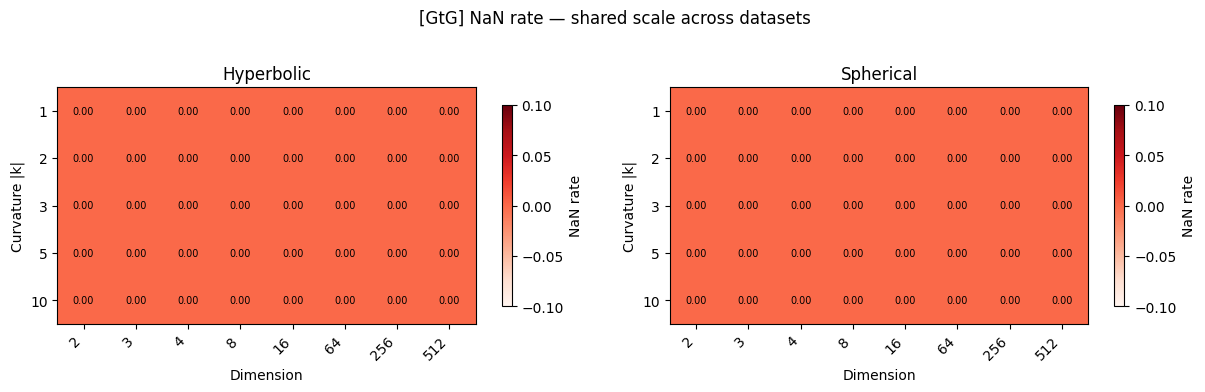

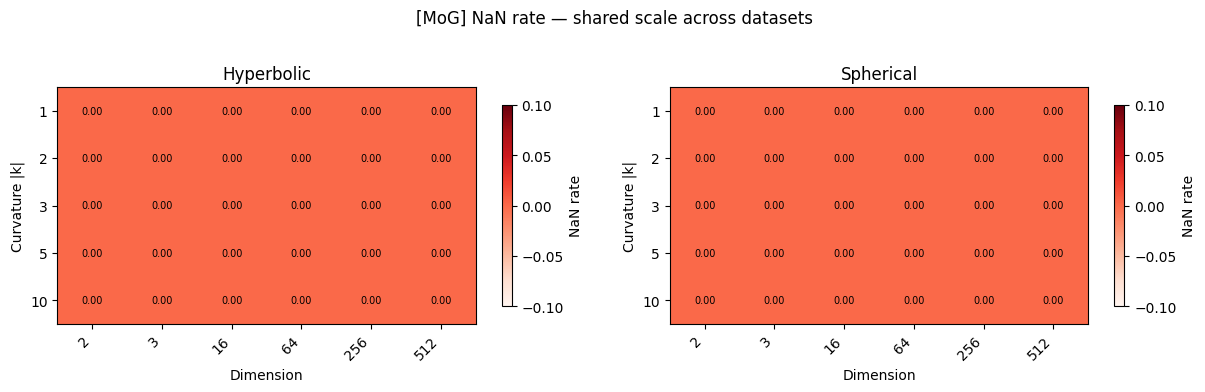

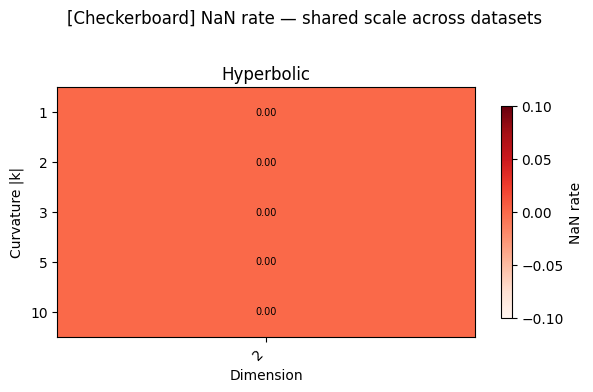

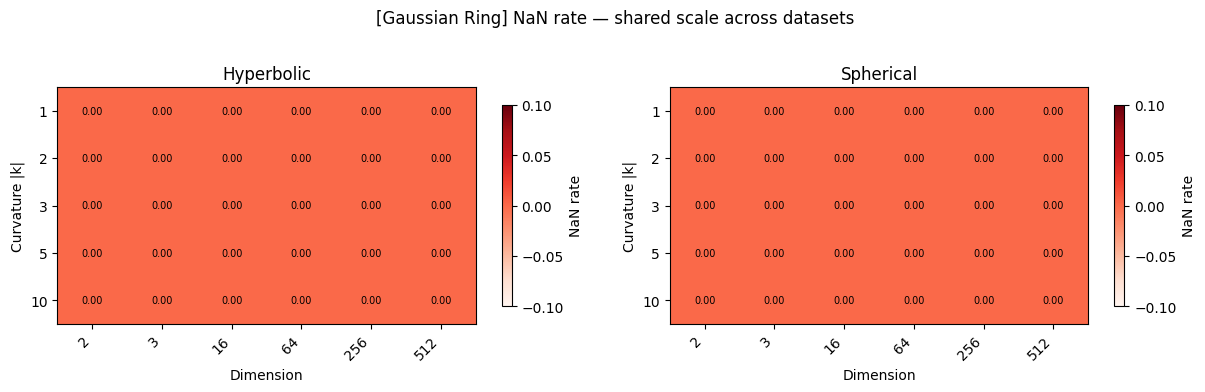

In [102]:
_all_nan = []
_nan_surfaces = {}
for name, df in prepared.items():
    df2 = df.copy()
    df2["nan_rate"] = 1.0 - pd.to_numeric(df2.get("test_vec/finite_fraction"), errors="coerce")
    sub_df = df2[~df2[MANIFOLD_COL].eq(EUCLIDEAN_NAME)].copy()
    rows = []
    for keys, sub in sub_df.groupby([MANIFOLD_COL, CURV_COL, "compare_dim"], dropna=False):
        m_name, curv, dim = keys
        mean, _, _ = mean_sem(sub["nan_rate"].replace([np.inf, -np.inf], np.nan))
        rows.append({MANIFOLD_COL: m_name, CURV_COL: curv, "compare_dim": dim, "mean": mean})
    s = pd.DataFrame(rows)
    _nan_surfaces[name] = s
    v = s["mean"].replace([np.inf, -np.inf], np.nan)
    _all_nan.append(np.nanmax(v))

_nan_vmax = max(_all_nan)

for name, s in _nan_surfaces.items():
    manifolds_in = [m for m in [POINCARE_NAME, SPHERE_NAME]
                    if m in s[MANIFOLD_COL].unique()]
    fig, axes = plt.subplots(1, len(manifolds_in),
                             figsize=(6.2 * len(manifolds_in), 3.8), squeeze=False)
    axes = axes[0]
    for ax, manifold in zip(axes, manifolds_in):
        sub   = s[s[MANIFOLD_COL].eq(manifold)]
        dims  = ordered_values_numeric(sub["compare_dim"])
        curvs = ordered_values_numeric(sub[CURV_COL], use_abs=True)
        pivot = (
            sub.pivot_table(index=CURV_COL, columns="compare_dim",
                            values="mean", aggfunc="mean")
            .reindex(index=curvs, columns=dims)
        )
        im = ax.imshow(pivot.values, aspect="auto", cmap="Reds",
                       vmin=0, vmax=_nan_vmax, interpolation="nearest")
        ax.set_xticks(range(len(dims)))
        ax.set_xticklabels([nice_dim_label(d) for d in dims], rotation=45, ha="right")
        ax.set_yticks(range(len(curvs)))
        ax.set_yticklabels([nice_curv_label(c) for c in curvs])
        ax.set_xlabel("Dimension"); ax.set_ylabel("Curvature |k|")
        ax.set_title(display_manifold_name(manifold))
        for ri in range(pivot.shape[0]):
            for ci in range(pivot.shape[1]):
                v = pivot.iloc[ri, ci]
                if not np.isnan(v):
                    ax.text(ci, ri, f"{v:.2f}", ha="center", va="center", fontsize=7)
        plt.colorbar(im, ax=ax, label="NaN rate", shrink=0.85)
    fig.suptitle(f"[{name}] NaN rate — shared scale across datasets",
                 fontsize=12, y=1.02)
    fig.tight_layout()
    plt.show()

### 5.7 Training cost (NFE) across datasets

All NFE tables concatenated into one for direct comparison across datasets and manifolds.

In [86]:
_nfe_frames = []
for name, df_prep in prepared.items():
    df_raw = raw[name]
    tbl = make_training_time_table(df_raw, df_prep)
    if tbl is not None:
        tbl.insert(0, "Dataset", name)
        _nfe_frames.append(tbl)

if _nfe_frames:
    display(pd.concat(_nfe_frames, ignore_index=True))
else:
    print("No NFE data found across any dataset.")

,Dataset,Manifold,Dimension,Mean NFE,SEM,n runs
0,GtG,Euclidean,2,43.3,5.1,3
1,GtG,Euclidean,3,39.8,2.1,3
2,GtG,Euclidean,4,36.0,2.0,3
3,GtG,Euclidean,8,36.0,2.0,3
4,GtG,Euclidean,16,31.0,5.5,3
...,...,...,...,...,...,...
57,Gaussian Ring,Spherical,3,62.4,2.3,45
58,Gaussian Ring,Spherical,16,53.8,1.3,45
59,Gaussian Ring,Spherical,64,58.4,1.1,45
60,Gaussian Ring,Spherical,256,75.9,3.2,45


### Comparison accross different geometeries

In [87]:
MANIFOLD_COLORS = {
    POINCARE_NAME:  "#8B1A1A",   # deep red  — Hyperbolic
    SPHERE_NAME:    "#185FA5",   # blue      — Spherical
    EUCLIDEAN_NAME: "#2CA02C",   # green     — Euclidean
}
MANIFOLD_MARKERS = {
    POINCARE_NAME:  "o",
    SPHERE_NAME:    "^",
    EUCLIDEAN_NAME: "s",
}

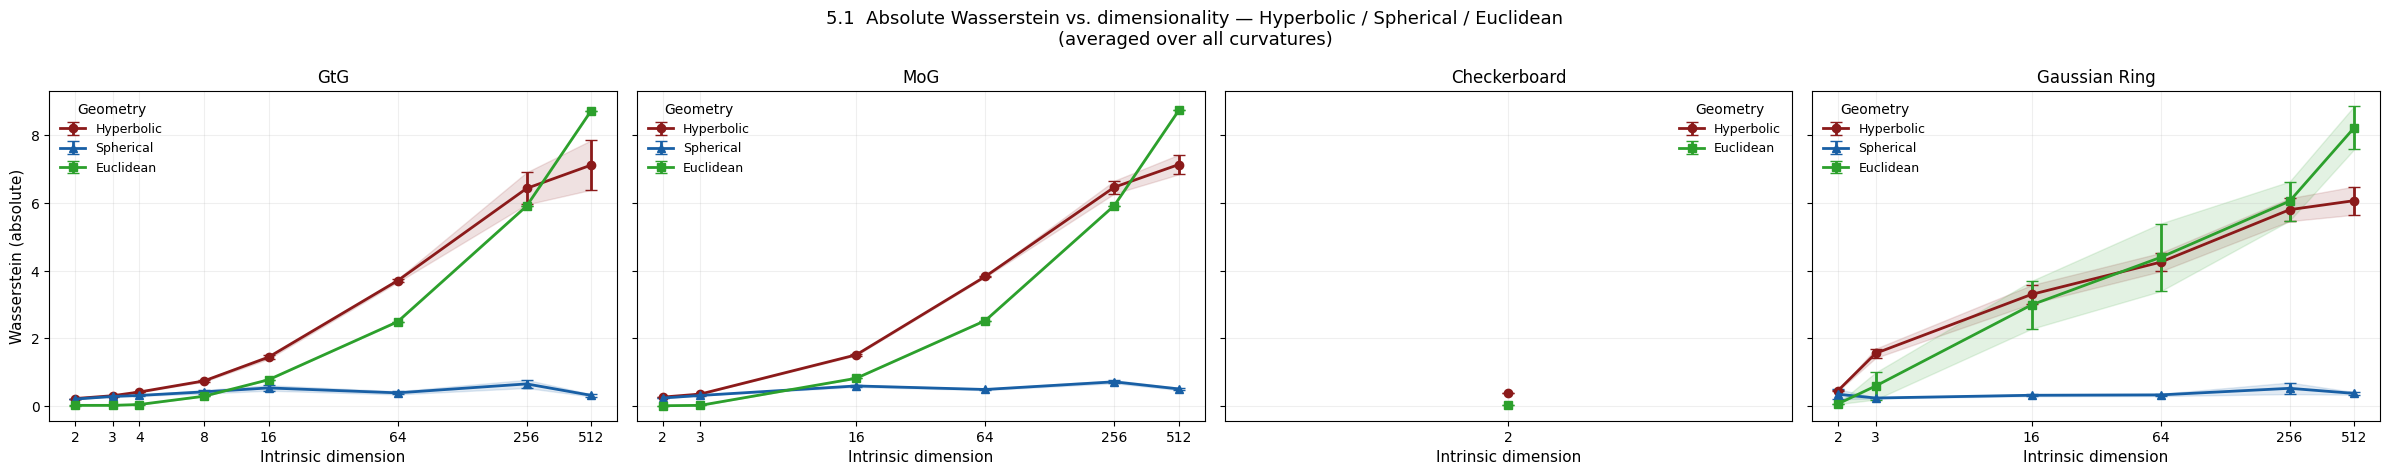

In [88]:
fig, axes = plt.subplots(
    1, len(prepared),
    figsize=(6.0 * len(prepared), 4.8),
    sharey=True,
)
if len(prepared) == 1:
    axes = [axes]

for ax, (name, df) in zip(axes, prepared.items()):
    df_plot = df.replace([np.inf, -np.inf], np.nan)
    for manifold in ordered_manifolds(df_plot[MANIFOLD_COL]):
        sub = (
            df_plot[df_plot[MANIFOLD_COL].eq(manifold)]
            .groupby("compare_dim", as_index=False)
            .agg(
                y_mean=(PERF_COL, "mean"),
                y_sem=(PERF_COL, lambda x: error_value(x, ERROR_BAR)),
            )
            .sort_values("compare_dim")
        )
        if sub.empty:
            continue
        color  = MANIFOLD_COLORS.get(manifold, "grey")
        marker = MANIFOLD_MARKERS.get(manifold, "o")
        d, ym, ys = sub["compare_dim"].values, sub["y_mean"].values, sub["y_sem"].values
        ax.fill_between(d, ym - ys, ym + ys, alpha=0.13, color=color)
        ax.errorbar(d, ym, yerr=ys, fmt=f"{marker}-", color=color,
                    markersize=6, capsize=4, linewidth=2,
                    label=display_manifold_name(manifold))
    ax.set_xscale("log", base=2)
    dims_all = sorted(df_plot["compare_dim"].dropna().unique())
    ax.set_xticks(dims_all)
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.set_xlabel("Intrinsic dimension", fontsize=11)
    ax.set_title(name, fontsize=12)
    ax.legend(frameon=False, title="Geometry", fontsize=9)
    ax.grid(alpha=0.2)

axes[0].set_ylabel("Wasserstein (absolute)", fontsize=11)
fig.suptitle(
    "5.1  Absolute Wasserstein vs. dimensionality — Hyperbolic / Spherical / Euclidean\n"
    "(averaged over all curvatures)",
    fontsize=13,
)
fig.tight_layout()
plt.show()

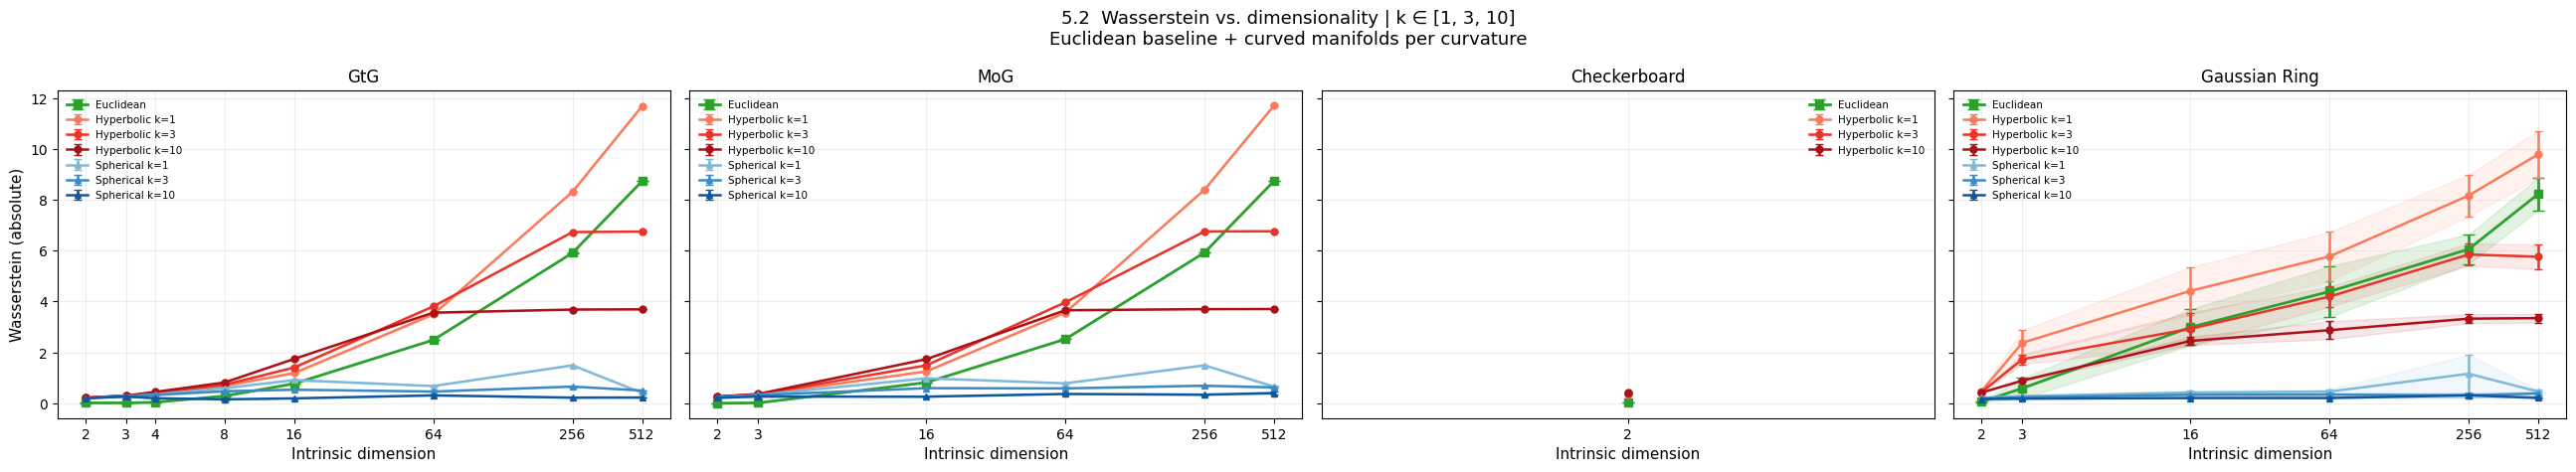

In [89]:
fig, axes = plt.subplots(
    1, len(prepared),
    figsize=(6.5 * len(prepared), 4.8),
    sharey=True,
)
if len(prepared) == 1:
    axes = [axes]

for ax, (name, df) in zip(axes, prepared.items()):
    df_plot = df.replace([np.inf, -np.inf], np.nan)

    # Euclidean baseline (no curvature axis)
    euc_sub = (
        df_plot[df_plot[MANIFOLD_COL].eq(EUCLIDEAN_NAME)]
        .groupby("compare_dim", as_index=False)
        .agg(
            y_mean=(PERF_COL, "mean"),
            y_sem=(PERF_COL, lambda x: error_value(x, ERROR_BAR)),
        )
        .sort_values("compare_dim")
    )
    if not euc_sub.empty:
        color = MANIFOLD_COLORS[EUCLIDEAN_NAME]
        d, ym, ys = euc_sub["compare_dim"].values, euc_sub["y_mean"].values, euc_sub["y_sem"].values
        ax.fill_between(d, ym - ys, ym + ys, alpha=0.13, color=color)
        ax.errorbar(d, ym, yerr=ys, fmt="s-", color=color, markersize=6,
                    capsize=4, linewidth=2, label="Euclidean")

    # Curved manifolds — one line per (manifold, curvature) combination
    curved = df_plot[
        df_plot[MANIFOLD_COL].isin([POINCARE_NAME, SPHERE_NAME]) &
        df_plot[CURV_COL].isin(SELECTED_CURVATURES)
    ]
    all_curvs = ordered_curvatures(curved[CURV_COL], order=CURVATURE_ORDER)
    cmap_hyp  = plt.cm.Reds
    cmap_sph  = plt.cm.Blues
    curv_vals = np.linspace(0.45, 0.85, len(all_curvs))
    curv_idx  = {c: i for i, c in enumerate(all_curvs)}

    for manifold, cmap in [(POINCARE_NAME, cmap_hyp), (SPHERE_NAME, cmap_sph)]:
        marker = MANIFOLD_MARKERS.get(manifold, "o")
        label_base = display_manifold_name(manifold)
        for curvature in all_curvs:
            sub = (
                curved[
                    curved[MANIFOLD_COL].eq(manifold) &
                    curved[CURV_COL].eq(curvature)
                ]
                .groupby("compare_dim", as_index=False)
                .agg(
                    y_mean=(PERF_COL, "mean"),
                    y_sem=(PERF_COL, lambda x: error_value(x, ERROR_BAR)),
                )
                .sort_values("compare_dim")
            )
            if sub.empty:
                continue
            color = cmap(curv_vals[curv_idx[curvature]])
            d, ym, ys = sub["compare_dim"].values, sub["y_mean"].values, sub["y_sem"].values
            ax.fill_between(d, ym - ys, ym + ys, alpha=0.10, color=color)
            ax.errorbar(d, ym, yerr=ys, fmt=f"{marker}-", color=color,
                        markersize=5, capsize=3, linewidth=1.8,
                        label=f"{label_base} k={nice_curv_label(curvature)}")

    ax.set_xscale("log", base=2)
    dims_all = sorted(df_plot["compare_dim"].dropna().unique())
    ax.set_xticks(dims_all)
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.set_xlabel("Intrinsic dimension", fontsize=11)
    ax.set_title(name, fontsize=12)
    ax.legend(frameon=False, fontsize=7.5, ncol=1)
    ax.grid(alpha=0.2)

axes[0].set_ylabel("Wasserstein (absolute)", fontsize=11)
fig.suptitle(
    f"5.2  Wasserstein vs. dimensionality | k ∈ {SELECTED_CURVATURES}\n"
    "Euclidean baseline + curved manifolds per curvature",
    fontsize=13,
)
fig.tight_layout()
plt.show()

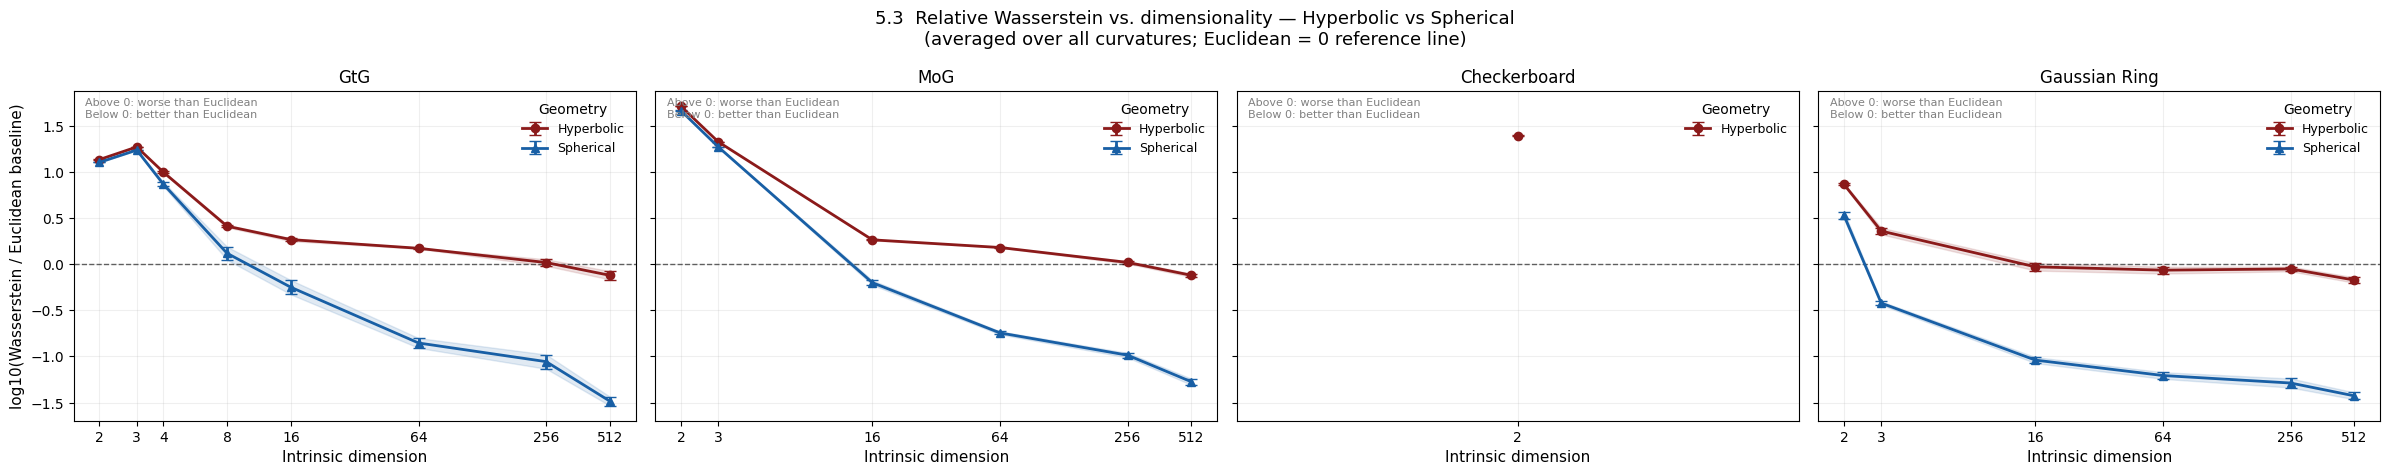

In [90]:
fig, axes = plt.subplots(
    1, len(prepared),
    figsize=(6.0 * len(prepared), 4.8),
    sharey=True,
)
if len(prepared) == 1:
    axes = [axes]

for ax, (name, df) in zip(axes, prepared.items()):
    df_plot = df.replace([np.inf, -np.inf], np.nan)
    for manifold in [POINCARE_NAME, SPHERE_NAME]:
        if manifold not in df_plot[MANIFOLD_COL].values:
            continue
        sub = (
            df_plot[df_plot[MANIFOLD_COL].eq(manifold)]
            .groupby("compare_dim", as_index=False)
            .agg(
                y_mean=("log_rel_perf", "mean"),
                y_sem=("log_rel_perf", lambda x: error_value(x, ERROR_BAR)),
            )
            .sort_values("compare_dim")
        )
        if sub.empty:
            continue
        color  = MANIFOLD_COLORS.get(manifold, "grey")
        marker = MANIFOLD_MARKERS.get(manifold, "o")
        d, ym, ys = sub["compare_dim"].values, sub["y_mean"].values, sub["y_sem"].values
        ax.fill_between(d, ym - ys, ym + ys, alpha=0.13, color=color)
        ax.errorbar(d, ym, yerr=ys, fmt=f"{marker}-", color=color,
                    markersize=6, capsize=4, linewidth=2,
                    label=display_manifold_name(manifold))
    ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.6)
    ax.set_xscale("log", base=2)
    dims_all = sorted(df_plot["compare_dim"].dropna().unique())
    ax.set_xticks(dims_all)
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.set_xlabel("Intrinsic dimension", fontsize=11)
    ax.set_title(name, fontsize=12)
    ax.legend(frameon=False, title="Geometry", fontsize=9)
    ax.grid(alpha=0.2)
    ax.text(0.02, 0.98,
            "Above 0: worse than Euclidean\nBelow 0: better than Euclidean",
            transform=ax.transAxes, fontsize=8, va="top", color="grey")

axes[0].set_ylabel("log10(Wasserstein / Euclidean baseline)", fontsize=11)
fig.suptitle(
    "5.3  Relative Wasserstein vs. dimensionality — Hyperbolic vs Spherical\n"
    "(averaged over all curvatures; Euclidean = 0 reference line)",
    fontsize=13,
)
fig.tight_layout()
plt.show()

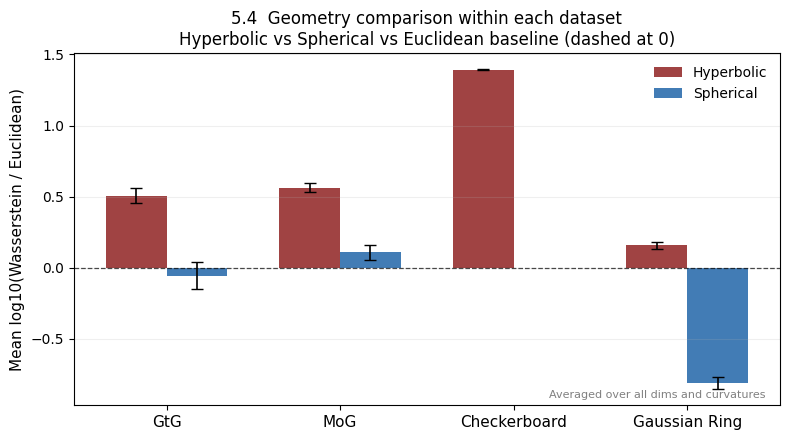

In [91]:
summary_rows = []
for name, df in prepared.items():
    df_plot = df.replace([np.inf, -np.inf], np.nan)
    for manifold in [POINCARE_NAME, SPHERE_NAME]:
        vals = df_plot.loc[df_plot[MANIFOLD_COL].eq(manifold), "log_rel_perf"].dropna()
        mean, sem, n = mean_sem(vals)
        summary_rows.append({
            "Dataset":  name,
            "Manifold": manifold,
            "mean":     mean,
            "sem":      sem,
            "n":        n,
        })

summary_df = pd.DataFrame(summary_rows)
datasets   = list(prepared.keys())
manifolds  = [POINCARE_NAME, SPHERE_NAME]
x          = np.arange(len(datasets))
width      = 0.35

fig, ax = plt.subplots(figsize=(8, 4.5))
for i, manifold in enumerate(manifolds):
    sub    = summary_df[summary_df["Manifold"].eq(manifold)]
    means  = [sub.loc[sub["Dataset"].eq(d), "mean"].values[0]
               if d in sub["Dataset"].values else np.nan for d in datasets]
    sems   = [sub.loc[sub["Dataset"].eq(d), "sem"].values[0]
               if d in sub["Dataset"].values else 0.0  for d in datasets]
    color  = MANIFOLD_COLORS[manifold]
    offset = (i - 0.5) * width
    ax.bar(x + offset, means, width, yerr=sems, label=display_manifold_name(manifold),
           color=color, alpha=0.82, capsize=4, error_kw={"linewidth": 1.2})

ax.axhline(0, color="black", linewidth=0.9, linestyle="--", alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(datasets, fontsize=11)
ax.set_ylabel("Mean log10(Wasserstein / Euclidean)", fontsize=11)
ax.set_title(
    "5.4  Geometry comparison within each dataset\n"
    "Hyperbolic vs Spherical vs Euclidean baseline (dashed at 0)",
    fontsize=12,
)
ax.legend(frameon=False, fontsize=10)
ax.grid(axis="y", alpha=0.2)
ax.text(0.98, 0.02, "Averaged over all dims and curvatures",
        transform=ax.transAxes, fontsize=8, ha="right", color="grey")
fig.tight_layout()
plt.show()

,Dataset,Manifold,Spearman ρ,p-value,n
0,GtG,Hyperbolic,0.317,0.014,60
1,GtG,Spherical,0.164,0.081,114
2,MoG,Hyperbolic,0.687,0.000,266
3,MoG,Spherical,0.224,0.000,480
4,Checkerboard,Hyperbolic,0.707,0.000,45
5,Checkerboard,Spherical,NaN,---,0
6,Gaussian Ring,Hyperbolic,-0.553,0.000,131
7,Gaussian Ring,Spherical,-0.364,0.000,266


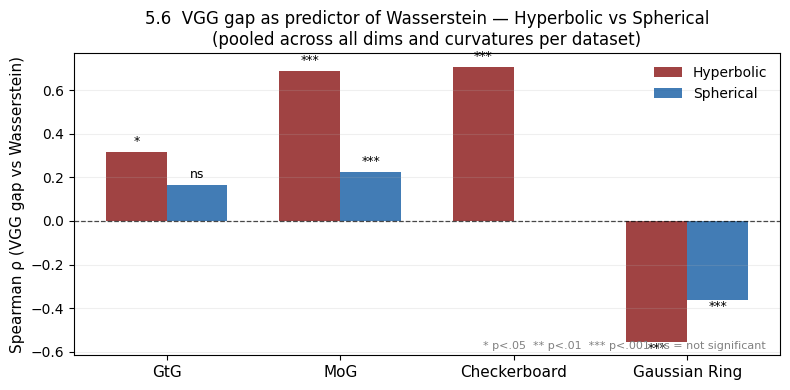

In [92]:
rho_rows = []
for name, df in prepared.items():
    df_plot = df.replace([np.inf, -np.inf], np.nan)
    for manifold in [POINCARE_NAME, SPHERE_NAME]:
        sub = df_plot[df_plot[MANIFOLD_COL].eq(manifold)].dropna(
            subset=["log_rel_perf", "signed_log_vgg_gap"]
        )
        if len(sub) >= 3:
            rho, pval = stats.spearmanr(sub["signed_log_vgg_gap"], sub["log_rel_perf"])
        else:
            rho, pval = np.nan, np.nan
        sig = ("***" if pval < 0.001 else "**" if pval < 0.01
               else "*" if pval < 0.05 else "ns") if not np.isnan(pval) else ""
        rho_rows.append({
            "Dataset":  name,
            "Manifold": display_manifold_name(manifold),
            "Spearman ρ": round(rho, 3) if not np.isnan(rho) else float("nan"),
            "p-value":  f"{pval:.3f}" if not np.isnan(pval) else "---",
            "sig":      sig,
            "n":        len(sub),
        })

rho_summary_df = pd.DataFrame(rho_rows)
display(rho_summary_df.drop(columns=["sig"]))

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
x      = np.arange(len(datasets))
width  = 0.35
for i, manifold in enumerate(manifolds):
    label = display_manifold_name(manifold)
    sub   = rho_summary_df[rho_summary_df["Manifold"].eq(label)]
    rhos  = [sub.loc[sub["Dataset"].eq(d), "Spearman ρ"].values[0]
              if d in sub["Dataset"].values else np.nan for d in datasets]
    sigs_ = [sub.loc[sub["Dataset"].eq(d), "sig"].values[0]
              if d in sub["Dataset"].values else ""    for d in datasets]
    color  = MANIFOLD_COLORS[manifolds[i]]
    offset = (i - 0.5) * width
    bars   = ax.bar(x + offset, rhos, width, label=label,
                    color=color, alpha=0.82)
    for bar, sig in zip(bars, sigs_):
        yv = bar.get_height()
        if sig:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    yv + (0.02 if yv >= 0 else -0.06),
                    sig, ha="center", va="bottom", fontsize=9)

ax.axhline(0, color="black", linewidth=0.9, linestyle="--", alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(datasets, fontsize=11)
ax.set_ylabel("Spearman ρ (VGG gap vs Wasserstein)", fontsize=11)
ax.set_title(
    "5.6  VGG gap as predictor of Wasserstein — Hyperbolic vs Spherical\n"
    "(pooled across all dims and curvatures per dataset)",
    fontsize=12,
)
ax.legend(frameon=False, fontsize=10)
ax.grid(axis="y", alpha=0.2)
ax.text(0.98, 0.02, "* p<.05  ** p<.01  *** p<.001  ns = not significant",
        transform=ax.transAxes, fontsize=8, ha="right", color="grey")
fig.tight_layout()
plt.show()

,Dataset,Geometry,Best Curvature k,Mean Wasserstein,SEM,log10(vs Euc),n runs
0,GtG,Hyperbolic,10,1.9686,0.3417,0.454,21
1,GtG,Spherical,10,0.2261,0.0098,-0.262,22
2,MoG,Hyperbolic,10,2.2567,0.1478,0.488,107
3,MoG,Spherical,10,0.2965,0.0080,-0.040,96
4,Checkerboard,Hyperbolic,1,0.3464,0.0044,1.358,9
5,Gaussian Ring,Hyperbolic,10,2.2698,0.1777,-0.008,52
6,Gaussian Ring,Spherical,10,0.2175,0.0171,-0.913,54


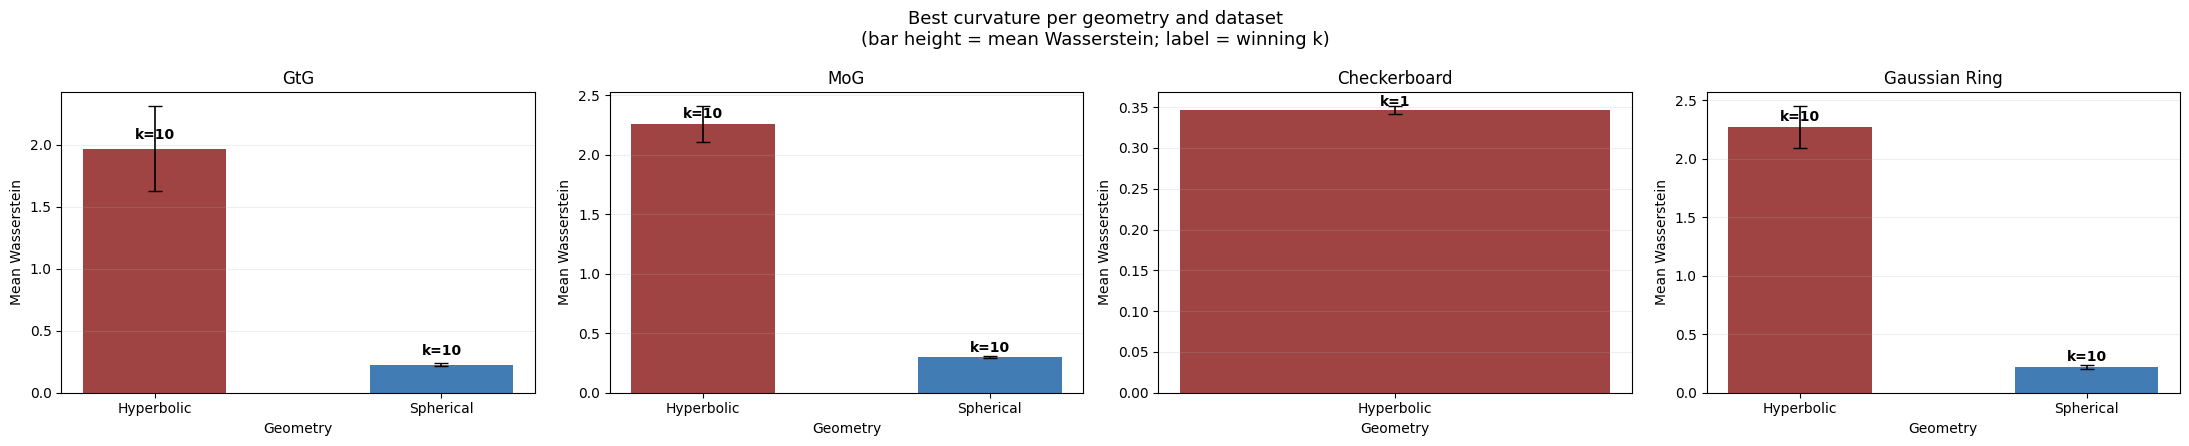

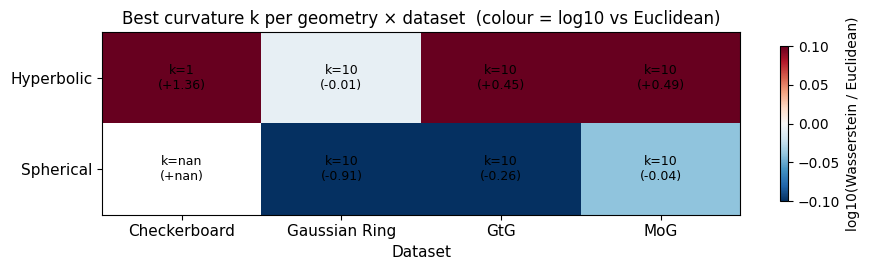

In [93]:
best_rows = []
for name, df in prepared.items():
    df_plot = df.replace([np.inf, -np.inf], np.nan)

    for manifold in [POINCARE_NAME, SPHERE_NAME]:
        sub = df_plot[df_plot[MANIFOLD_COL].eq(manifold)]
        if sub.empty:
            continue

        grouped = (
            sub.groupby(CURV_COL, as_index=False)
            .agg(
                mean_wass=(PERF_COL, "mean"),
                sem_wass=(PERF_COL, lambda x: error_value(x, ERROR_BAR)),
                mean_log_rel=("log_rel_perf", "mean"),
                n=(PERF_COL, "count"),
            )
        )
        best_idx = grouped["mean_wass"].idxmin()
        best     = grouped.loc[best_idx]

        best_rows.append({
            "Dataset":           name,
            "Geometry":          display_manifold_name(manifold),
            "Best Curvature k":  nice_curv_label(best[CURV_COL]),
            "Mean Wasserstein":  round(best["mean_wass"], 4),
            "SEM":               round(best["sem_wass"],  4),
            "log10(vs Euc)":     round(best["mean_log_rel"], 3),
            "n runs":            int(best["n"]),
        })

best_df = pd.DataFrame(best_rows)
display(best_df)

# --- Bar chart: best curvature value per dataset × geometry ---------------
fig, axes = plt.subplots(1, len(prepared), figsize=(5.5 * len(prepared), 4.5), sharey=False)
if len(prepared) == 1:
    axes = [axes]

for ax, (name, df) in zip(axes, prepared.items()):
    df_plot  = df.replace([np.inf, -np.inf], np.nan)
    subset   = best_df[best_df["Dataset"].eq(name)]

    geoms    = subset["Geometry"].tolist()
    wass     = subset["Mean Wasserstein"].tolist()
    sems     = subset["SEM"].tolist()
    curvs    = subset["Best Curvature k"].tolist()
    colors   = [MANIFOLD_COLORS.get(
                    {v: k for k, v in {POINCARE_NAME: "Hyperbolic",
                                        SPHERE_NAME:   "Spherical"}.items()}.get(g, g), "grey")
                for g in geoms]

    bars = ax.bar(geoms, wass, yerr=sems, color=colors, alpha=0.82,
                  capsize=5, width=0.5, error_kw={"linewidth": 1.2})

    # Annotate each bar with the winning curvature
    for bar, k_label in zip(bars, curvs):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(sems) * 0.15,
            f"k={k_label}",
            ha="center", va="bottom", fontsize=10, fontweight="bold",
        )

    ax.set_title(name, fontsize=12)
    ax.set_ylabel("Mean Wasserstein", fontsize=10)
    ax.set_xlabel("Geometry", fontsize=10)
    ax.grid(axis="y", alpha=0.2)

fig.suptitle(
    "Best curvature per geometry and dataset\n"
    "(bar height = mean Wasserstein; label = winning k)",
    fontsize=13,
)
fig.tight_layout()
plt.show()

# --- Heatmap: best curvature k across dataset × geometry ------------------
pivot_best = best_df.pivot(index="Geometry", columns="Dataset", values="Best Curvature k")
pivot_wass = best_df.pivot(index="Geometry", columns="Dataset", values="log10(vs Euc)")

fig, ax = plt.subplots(figsize=(1.8 * len(prepared) + 2, 2.8))
numeric_pivot = pivot_wass.astype(float)
im = ax.imshow(numeric_pivot.values, cmap="RdBu_r", aspect="auto",
               vmin=-abs(numeric_pivot.values).max(),
               vmax= abs(numeric_pivot.values).max())

ax.set_xticks(range(len(pivot_best.columns)))
ax.set_xticklabels(pivot_best.columns, fontsize=11)
ax.set_yticks(range(len(pivot_best.index)))
ax.set_yticklabels(pivot_best.index, fontsize=11)
ax.set_xlabel("Dataset", fontsize=11)

# Annotate with best k value
for ri in range(numeric_pivot.shape[0]):
    for ci in range(numeric_pivot.shape[1]):
        k_val   = pivot_best.iloc[ri, ci]
        rel_val = numeric_pivot.iloc[ri, ci]
        tc = "white" if abs(rel_val) > 0.4 * abs(numeric_pivot.values).max() else "black"
        ax.text(ci, ri, f"k={k_val}\n({rel_val:+.2f})",
                ha="center", va="center", fontsize=9, color=tc)

plt.colorbar(im, ax=ax, label="log10(Wasserstein / Euclidean)", shrink=0.85)
ax.set_title("Best curvature k per geometry × dataset  (colour = log10 vs Euclidean)",
             fontsize=12)
fig.tight_layout()
plt.show()

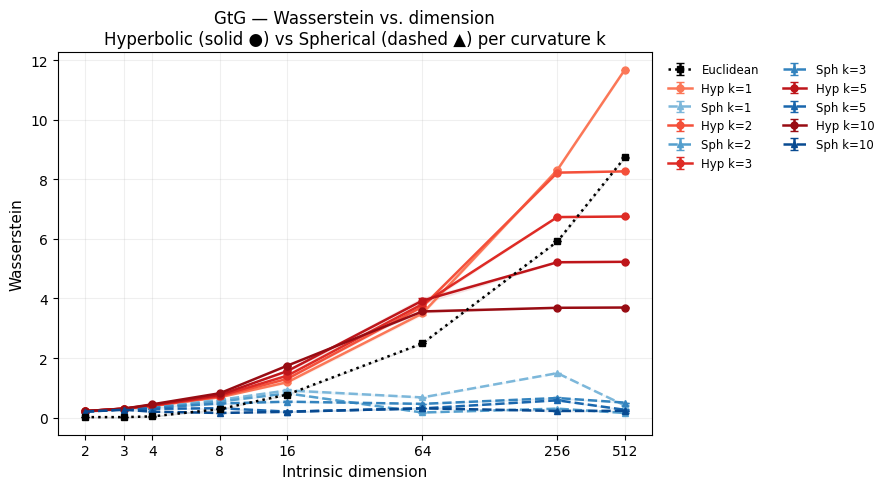

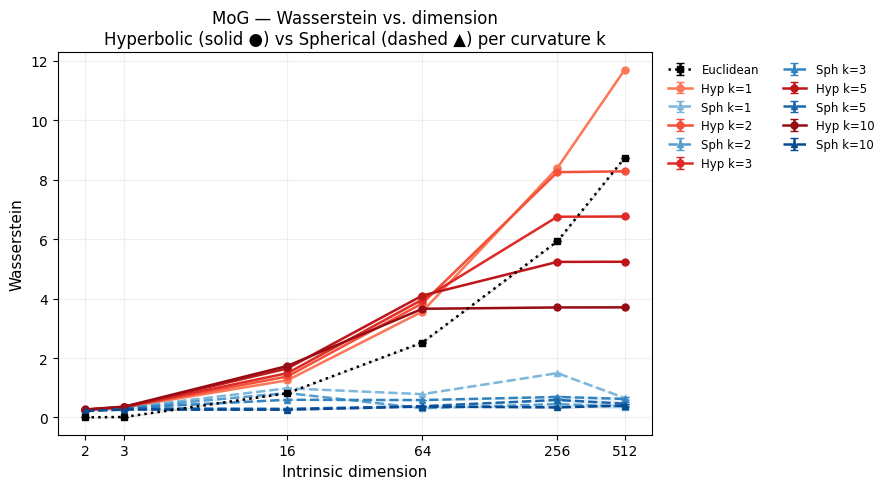

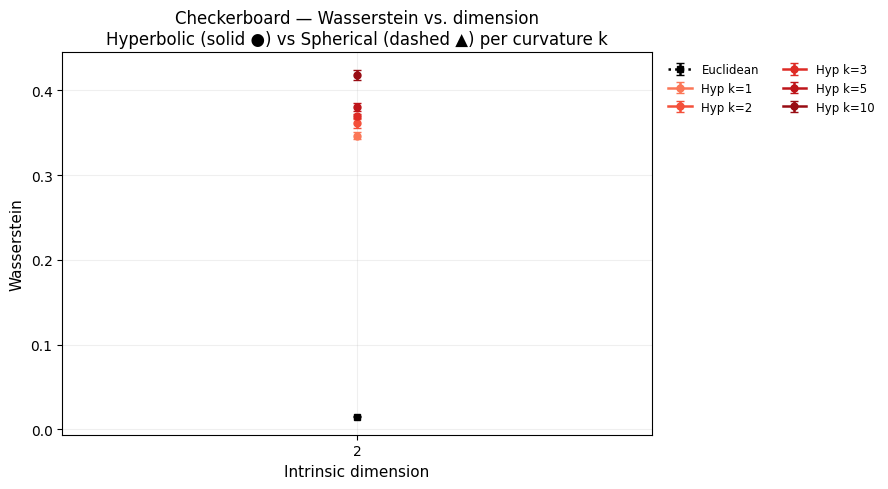

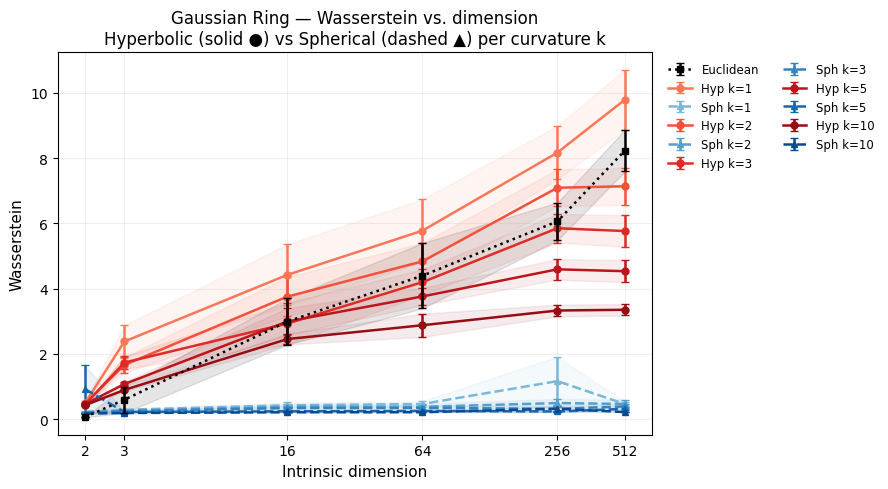

In [94]:
all_curvs  = sorted(set(
    c for df in prepared.values()
    for c in df[CURV_COL].dropna().unique()
))
n_curvs    = len(all_curvs)
red_map    = plt.cm.Reds(np.linspace(0.35, 0.90, n_curvs))
blue_map   = plt.cm.Blues(np.linspace(0.35, 0.90, n_curvs))
curv_color = {c: {"hyp": red_map[i], "sph": blue_map[i]}
              for i, c in enumerate(all_curvs)}

for name, df in prepared.items():
    df_plot = df.replace([np.inf, -np.inf], np.nan)
    curvs   = ordered_curvatures(df_plot[CURV_COL].dropna().unique(), order=CURVATURE_ORDER)

    fig, ax = plt.subplots(figsize=(9, 5))

    # --- Euclidean baseline ---
    euc = (
        df_plot[df_plot[MANIFOLD_COL].eq(EUCLIDEAN_NAME)]
        .groupby("compare_dim", as_index=False)
        .agg(y_mean=(PERF_COL, "mean"),
             y_sem=(PERF_COL, lambda x: error_value(x, ERROR_BAR)))
        .sort_values("compare_dim")
    )
    if not euc.empty:
        d, ym, ys = euc["compare_dim"].values, euc["y_mean"].values, euc["y_sem"].values
        ax.fill_between(d, ym - ys, ym + ys, alpha=0.10, color="black")
        ax.errorbar(d, ym, yerr=ys, fmt="s:", color="black", linewidth=1.8,
                    markersize=5, capsize=3, label="Euclidean", zorder=5)

    # --- Hyperbolic & Spherical per curvature ---
    for curvature in curvs:
        cidx  = all_curvs.index(curvature)
        c_hyp = red_map[cidx]
        c_sph = blue_map[cidx]
        k_lbl = nice_curv_label(curvature)

        for manifold, color, ls, marker, geom_lbl in [
            (POINCARE_NAME, c_hyp, "-",  "o", "Hyp"),
            (SPHERE_NAME,   c_sph, "--", "^", "Sph"),
        ]:
            sub = (
                df_plot[
                    df_plot[MANIFOLD_COL].eq(manifold) &
                    df_plot[CURV_COL].eq(curvature)
                ]
                .groupby("compare_dim", as_index=False)
                .agg(y_mean=(PERF_COL, "mean"),
                     y_sem=(PERF_COL, lambda x: error_value(x, ERROR_BAR)))
                .sort_values("compare_dim")
            )
            if sub.empty:
                continue
            d, ym, ys = sub["compare_dim"].values, sub["y_mean"].values, sub["y_sem"].values
            ax.fill_between(d, ym - ys, ym + ys, alpha=0.08, color=color)
            ax.errorbar(d, ym, yerr=ys, fmt=f"{marker}{ls}", color=color,
                        linewidth=1.8, markersize=5, capsize=3,
                        label=f"{geom_lbl} k={k_lbl}")

    # --- Formatting ---
    dims_all = sorted(df_plot["compare_dim"].dropna().unique())
    ax.set_xscale("log", base=2)
    ax.set_xticks(dims_all)
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.set_xlabel("Intrinsic dimension", fontsize=11)
    ax.set_ylabel("Wasserstein", fontsize=11)
    ax.set_title(f"{name} — Wasserstein vs. dimension\n"
                 "Hyperbolic (solid ●) vs Spherical (dashed ▲) per curvature k",
                 fontsize=12)
    ax.legend(frameon=False, fontsize=8.5, ncol=2,
              loc="upper left", bbox_to_anchor=(1.01, 1))
    ax.grid(alpha=0.2)
    fig.tight_layout()
    plt.show()

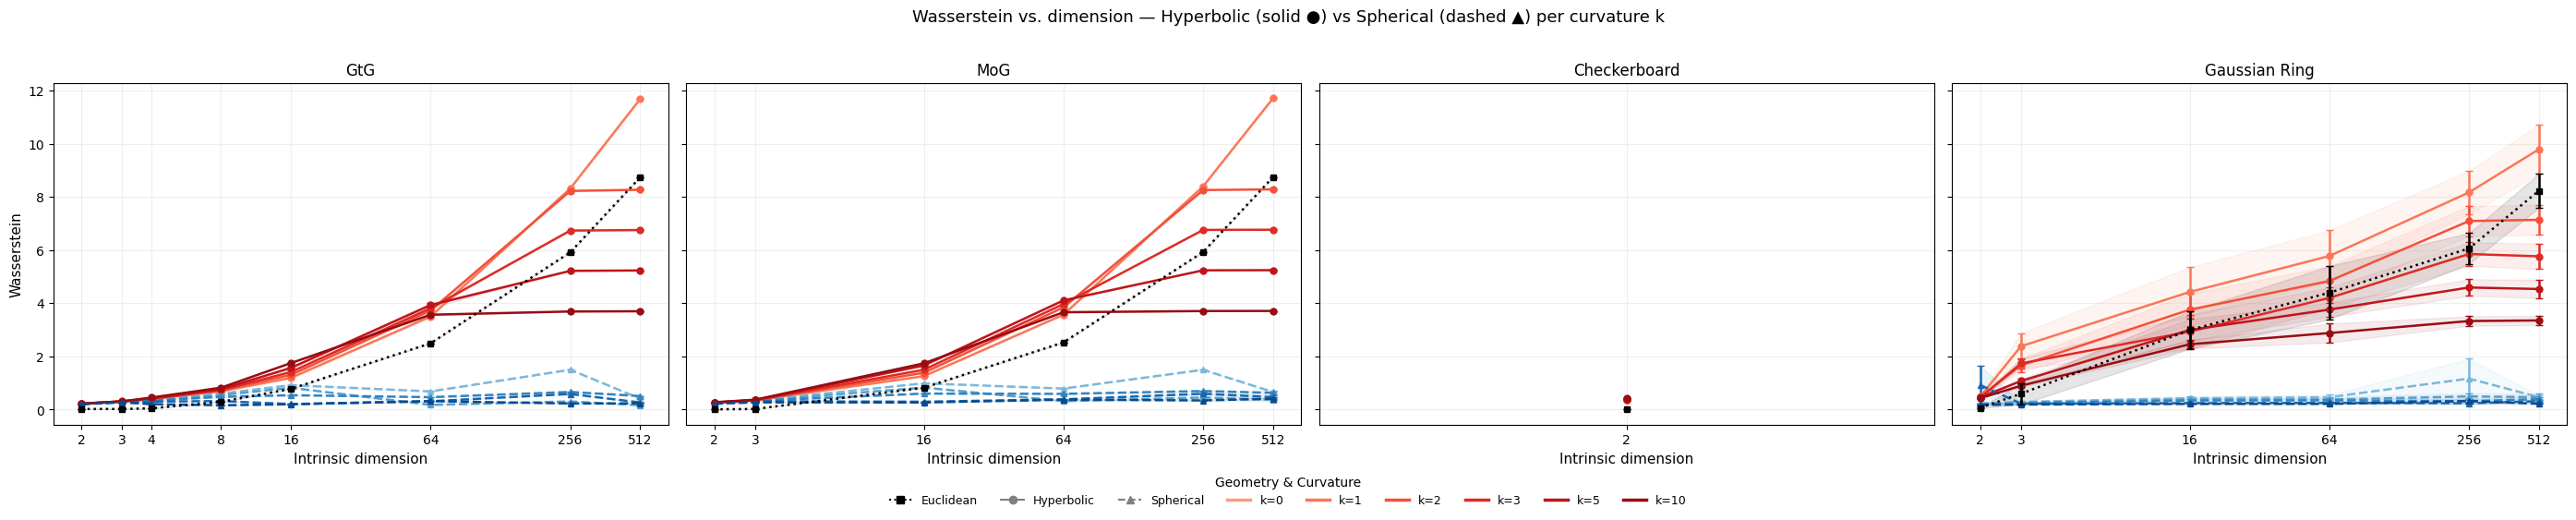

In [95]:
all_curvs = sorted(set(
    c for df in prepared.values()
    for c in df[CURV_COL].dropna().unique()
))
n_curvs  = len(all_curvs)
red_map  = plt.cm.Reds(np.linspace(0.35, 0.90, n_curvs))
blue_map = plt.cm.Blues(np.linspace(0.35, 0.90, n_curvs))

n_datasets = len(prepared)
fig, axes  = plt.subplots(1, n_datasets,
                           figsize=(7 * n_datasets, 5),
                           sharey=True)
if n_datasets == 1:
    axes = [axes]

for ax, (name, df) in zip(axes, prepared.items()):
    df_plot = df.replace([np.inf, -np.inf], np.nan)
    curvs   = ordered_curvatures(df_plot[CURV_COL].dropna().unique(), order=CURVATURE_ORDER)

    # --- Euclidean baseline ---
    euc = (
        df_plot[df_plot[MANIFOLD_COL].eq(EUCLIDEAN_NAME)]
        .groupby("compare_dim", as_index=False)
        .agg(y_mean=(PERF_COL, "mean"),
             y_sem=(PERF_COL, lambda x: error_value(x, ERROR_BAR)))
        .sort_values("compare_dim")
    )
    if not euc.empty:
        d, ym, ys = euc["compare_dim"].values, euc["y_mean"].values, euc["y_sem"].values
        ax.fill_between(d, ym - ys, ym + ys, alpha=0.10, color="black")
        ax.errorbar(d, ym, yerr=ys, fmt="s:", color="black", linewidth=1.8,
                    markersize=5, capsize=3, label="Euclidean", zorder=5)

    # --- Hyperbolic & Spherical per curvature ---
    for curvature in curvs:
        cidx  = all_curvs.index(curvature)
        c_hyp = red_map[cidx]
        c_sph = blue_map[cidx]
        k_lbl = nice_curv_label(curvature)

        for manifold, color, ls, marker, geom_lbl in [
            (POINCARE_NAME, c_hyp, "-",  "o", "Hyp"),
            (SPHERE_NAME,   c_sph, "--", "^", "Sph"),
        ]:
            sub = (
                df_plot[
                    df_plot[MANIFOLD_COL].eq(manifold) &
                    df_plot[CURV_COL].eq(curvature)
                ]
                .groupby("compare_dim", as_index=False)
                .agg(y_mean=(PERF_COL, "mean"),
                     y_sem=(PERF_COL, lambda x: error_value(x, ERROR_BAR)))
                .sort_values("compare_dim")
            )
            if sub.empty:
                continue
            d, ym, ys = sub["compare_dim"].values, sub["y_mean"].values, sub["y_sem"].values
            ax.fill_between(d, ym - ys, ym + ys, alpha=0.08, color=color)
            ax.errorbar(d, ym, yerr=ys, fmt=f"{marker}{ls}", color=color,
                        linewidth=1.8, markersize=5, capsize=3)

    # --- Formatting ---
    dims_all = sorted(df_plot["compare_dim"].dropna().unique())
    ax.set_xscale("log", base=2)
    ax.set_xticks(dims_all)
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.set_xlabel("Intrinsic dimension", fontsize=11)
    ax.set_title(name, fontsize=12)
    ax.grid(alpha=0.2)

axes[0].set_ylabel("Wasserstein", fontsize=11)

# --- Shared legend ---
# Geometry entries (line style)
legend_handles = [
    plt.Line2D([0], [0], color="black", ls=":",  marker="s", markersize=6, label="Euclidean"),
    plt.Line2D([0], [0], color="grey",  ls="-",  marker="o", markersize=6, label="Hyperbolic"),
    plt.Line2D([0], [0], color="grey",  ls="--", marker="^", markersize=6, label="Spherical"),
]
# Curvature entries (colour shade)
for i, curvature in enumerate(all_curvs):
    legend_handles.append(
        plt.Line2D([0], [0], color=red_map[i], ls="-", linewidth=2.5,
                   label=f"k={nice_curv_label(curvature)}")
    )

fig.legend(handles=legend_handles,
           title="Geometry & Curvature",
           title_fontsize=10,
           fontsize=9,
           frameon=False,
           loc="lower center",
           ncol=3 + len(all_curvs),
           bbox_to_anchor=(0.5, -0.08))

fig.suptitle("Wasserstein vs. dimension — Hyperbolic (solid ●) vs Spherical (dashed ▲) per curvature k",
             fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

In [97]:
# import warnings
# warnings.filterwarnings("ignore")

# for name, df in prepared.items():
#     df_plot = df.replace([np.inf, -np.inf], np.nan)
#     dims    = sorted(df_plot["compare_dim"].dropna().unique())
#     curvs   = sorted(df_plot[CURV_COL].dropna().unique())
#     manifolds = [POINCARE_NAME, SPHERE_NAME, EUCLIDEAN_NAME]

#     print(f"\n{'='*60}")
#     print(f"DATASET: {name}")
#     print(f"  dims={[int(d) if float(d).is_integer() else d for d in dims]}  curvatures={[nice_curv_label(c) for c in curvs]}")

#     # --- Per manifold x curvature: mean Wasserstein + log_rel_perf ---
#     print(f"\n  {'Manifold':<12} {'k':<6} {'dim':<6} {'Wass':>8}  {'log_rel':>8}  {'n':>4}")
#     print(f"  {'-'*50}")
#     for manifold in manifolds:
#         for curv in ([None] if manifold == EUCLIDEAN_NAME else curvs):
#             mask = df_plot[MANIFOLD_COL].eq(manifold)
#             if curv is not None:
#                 mask &= df_plot[CURV_COL].eq(curv)
#             sub = df_plot[mask]
#             if sub.empty:
#                 continue
#             for dim in dims:
#                 row = sub[sub["compare_dim"].eq(dim)]
#                 if row.empty:
#                     continue
#                 w   = row[PERF_COL].mean()
#                 lr  = row["log_rel_perf"].mean()
#                 n   = row[PERF_COL].count()
#                 k_s = nice_curv_label(curv) if curv is not None else "—"
#                 m_s = display_manifold_name(manifold)[:4]
#                 print(f"  {m_s:<12} {k_s:<6} {int(dim) if float(dim).is_integer() else dim:<6} {w:>8.4f}  {lr:>8.3f}  {n:>4}")

#     # --- Best curvature per geometry ---
#     print(f"\n  Best curvature (lowest mean Wasserstein, all dims pooled):")
#     for manifold in [POINCARE_NAME, SPHERE_NAME]:
#         grp = (
#             df_plot[df_plot[MANIFOLD_COL].eq(manifold)]
#             .groupby(CURV_COL)[PERF_COL].mean()
#         )
#         if grp.empty: continue
#         best_k = grp.idxmin()
#         print(f"    {display_manifold_name(manifold):<12} k={nice_curv_label(best_k):<6}  Wass={grp[best_k]:.4f}")

#     # --- Does curvature beat Euclidean? ---
#     euc_mean = df_plot[df_plot[MANIFOLD_COL].eq(EUCLIDEAN_NAME)][PERF_COL].mean()
#     print(f"\n  Euclidean mean Wasserstein (all dims): {euc_mean:.4f}")
#     for manifold in [POINCARE_NAME, SPHERE_NAME]:
#         sub = df_plot[df_plot[MANIFOLD_COL].eq(manifold)]
#         beats = (sub[PERF_COL] < euc_mean).sum()
#         total = sub[PERF_COL].count()
#         print(f"    {display_manifold_name(manifold):<12} beats Euclidean in {beats}/{total} runs  "
#               f"(mean log_rel={sub['log_rel_perf'].mean():.3f})")

# print(f"\n{'='*60}")


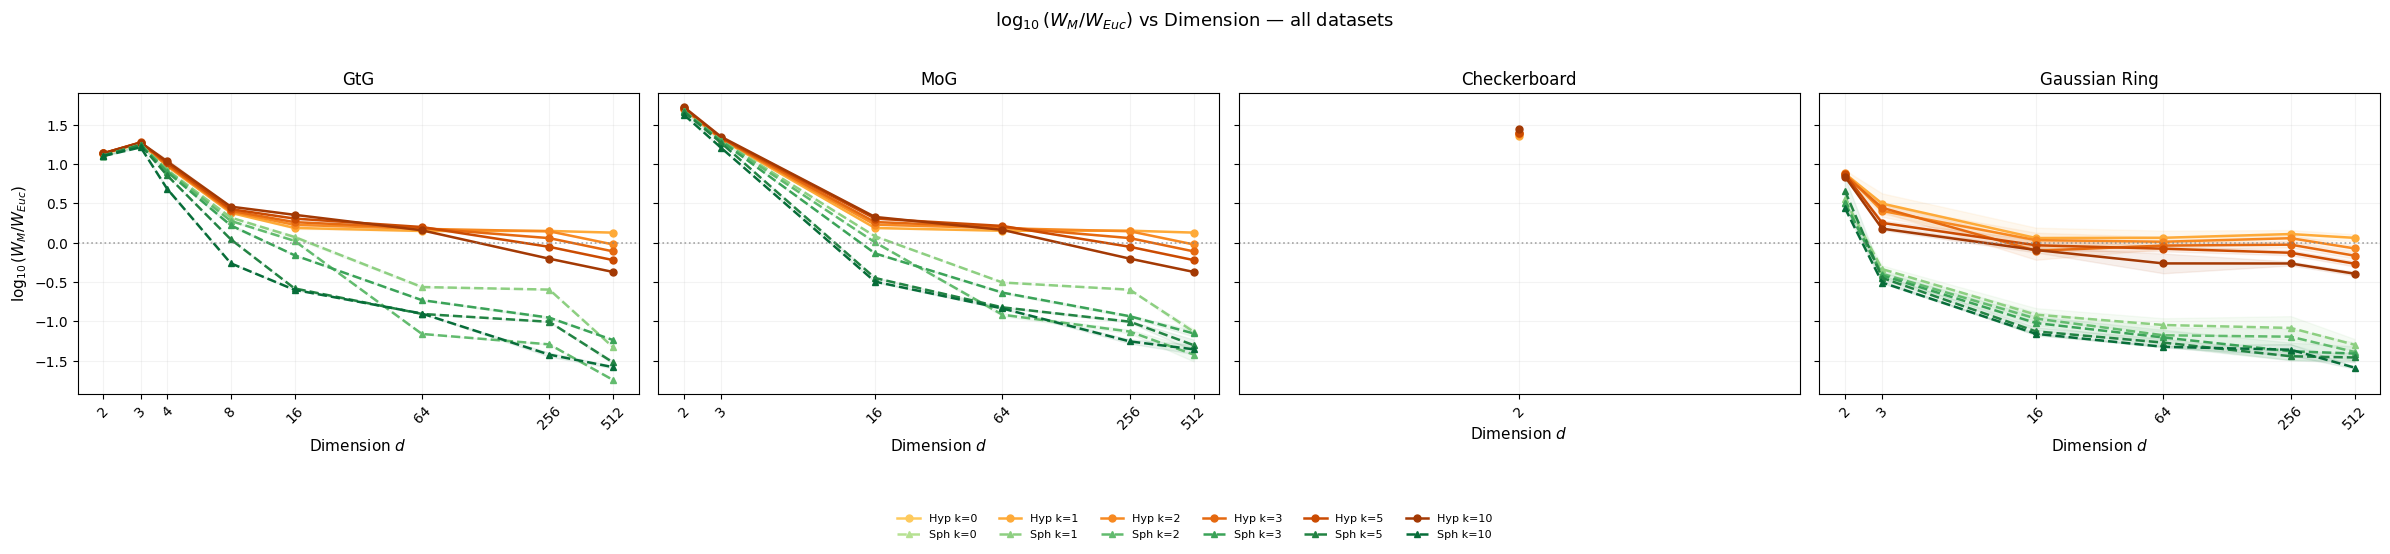

In [121]:
fig, axes = plt.subplots(1, len(prepared),
                         figsize=(6 * len(prepared), 4.5),
                         sharey=True)
if len(prepared) == 1:
    axes = [axes]

n_curvs   = len(all_curvs)
orange_map = plt.cm.YlOrBr(np.linspace(0.35, 0.85, n_curvs))
green_map  = plt.cm.YlGn(np.linspace(0.35, 0.85, n_curvs))

for ax, (name, df) in zip(axes, prepared.items()):
    df_plot = df.replace([np.inf, -np.inf], np.nan)
    curvs   = ordered_curvatures(df_plot[CURV_COL].dropna().unique(), order=CURVATURE_ORDER)

    for manifold, cmap, ls, marker in [
        (POINCARE_NAME, orange_map, "-",  "o"),
        (SPHERE_NAME,   green_map,  "--", "^"),
    ]:
        for i, curvature in enumerate(curvs):
            sub = (
                df_plot[
                    df_plot[MANIFOLD_COL].eq(manifold) &
                    df_plot[CURV_COL].eq(curvature)
                ]
                .groupby("compare_dim", as_index=False)
                .agg(
                    y_mean=("log_rel_perf", "mean"),
                    y_sem=("log_rel_perf", lambda x: error_value(x, ERROR_BAR)),
                )
                .sort_values("compare_dim")
            )
            if sub.empty:
                continue
            color = cmap[i]
            d, ym, ys = sub["compare_dim"].values, sub["y_mean"].values, sub["y_sem"].values
            ax.fill_between(d, ym - ys, ym + ys, alpha=0.08, color=color)
            ax.plot(d, ym, ls=ls, marker=marker, color=color,
                    markersize=5, linewidth=1.8,
                    label=f"{'Hyp' if manifold == POINCARE_NAME else 'Sph'} k={nice_curv_label(curvature)}")

    # Euclidean reference line at 0
    ax.axhline(0, color="grey", linestyle=":", linewidth=1.2, alpha=0.7)

    dims_all = sorted(df_plot["compare_dim"].dropna().unique())
    ax.set_xscale("log", base=2)
    ax.set_xticks(dims_all)
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.tick_params(axis="x", rotation=45)
    ax.set_xlabel("Dimension $d$", fontsize=11)
    ax.set_title(name, fontsize=12)
    ax.grid(alpha=0.15)

axes[0].set_ylabel(r"$\log_{10}(W_M / W_{Euc})$", fontsize=11)

# Shared legend — one entry per curvature, grouped by geometry
legend_handles = []
for i, curvature in enumerate(ordered_curvatures(
        list(set(c for df in prepared.values()
                 for c in df[CURV_COL].dropna().unique())),
        order=CURVATURE_ORDER)):
    legend_handles.append(
        plt.Line2D([0], [0], color=orange_map[i], ls="-", marker="o",
                   markersize=5, linewidth=1.8,
                   label=f"Hyp k={nice_curv_label(curvature)}")
    )
    legend_handles.append(
        plt.Line2D([0], [0], color=green_map[i], ls="--", marker="^",
                   markersize=5, linewidth=1.8,
                   label=f"Sph k={nice_curv_label(curvature)}")
    )

fig.legend(handles=legend_handles,
           fontsize=8, frameon=False,
           loc="lower center",
           ncol=len(all_curvs),
           bbox_to_anchor=(0.5, -0.18))

fig.suptitle(r"$\log_{10}(W_M / W_{Euc})$ vs Dimension — all datasets",
             fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

In [112]:
import shutil
import os

plot_dir = "/home/scur0108/DL2_project/Spherical-Flow-Matching/riemannian-fm/results/runs/checkerboard/plots"
out_dir  = "/home/scur0108/DL2_project/Spherical-Flow-Matching/riemannian-fm/selected_plots/checkerboard"

os.makedirs(out_dir, exist_ok=True)

to_pull = [
    "general__c0_std0.5_fourier16_seed42_analysis.pdf",
    "general__c1_std0.5_fourier16_seed42_analysis.pdf",
    "general__c10_std0.5_fourier16_seed42_analysis.pdf",
]

for fname in to_pull:
    src = os.path.join(plot_dir, fname)
    dst = os.path.join(out_dir, fname)
    shutil.copy(src, dst)
    print(f"Copied: {fname}")

print(f"\nAll saved to: {out_dir}")

Copied: general__c0_std0.5_fourier16_seed42_analysis.pdf
Copied: general__c1_std0.5_fourier16_seed42_analysis.pdf
Copied: general__c10_std0.5_fourier16_seed42_analysis.pdf

All saved to: /home/scur0108/DL2_project/Spherical-Flow-Matching/riemannian-fm/selected_plots/checkerboard


In [115]:
import shutil
import os

plot_dir = "/home/scur0108/DL2_project/Spherical-Flow-Matching/riemannian-fm/results/runs/checkerboard/plots"
out_dir  = "/home/scur0108/DL2_project/Spherical-Flow-Matching/riemannian-fm/selected_plots/checkerboard"

os.makedirs(out_dir, exist_ok=True)

# to_pull = [
#     "general__c0_std0.5_fourier16_seed42_analysis.pdf",
#     "general__c1_std0.5_fourier16_seed42_analysis.pdf",
#     "general__c10_std0.5_fourier16_seed42_analysis.pdf",
# ]
to_pull = [
    # your candidate
    "general__c2_std0.3_fourier16_seed34_analysis.pdf",
    # the controlled equivalent
    "general__c2_std0.5_fourier16_seed42_analysis.pdf",
]

for fname in to_pull:
    src = os.path.join(plot_dir, fname)
    dst = os.path.join(out_dir, fname)
    shutil.copy(src, dst)
    print(f"Copied: {fname}")

print(f"\nAll saved to: {out_dir}")

Copied: general__c2_std0.3_fourier16_seed34_analysis.pdf
Copied: general__c2_std0.5_fourier16_seed42_analysis.pdf

All saved to: /home/scur0108/DL2_project/Spherical-Flow-Matching/riemannian-fm/selected_plots/checkerboard


In [116]:
import os
import glob

for dataset in ["gtg", "mog", "gaussian_ring"]:
    plot_dir = f"/home/scur0108/DL2_project/Spherical-Flow-Matching/riemannian-fm/results/runs/{dataset}/plots"
    all_plots = sorted(glob.glob(os.path.join(plot_dir, "**", "*.pdf"), recursive=True))
    n = len(all_plots)
    third = n // 3

    print(f"\n{'='*60}")
    print(f"DATASET: {dataset}  |  total={n}  |  each section={third}")
    print(f"  --- Poincare (first {third}) ---")
    for p in all_plots[:third]:
        print(f"    {os.path.basename(p)}")
    print(f"  --- Euclidean (middle {third}) ---")
    for p in all_plots[third:2*third]:
        print(f"    {os.path.basename(p)}")
    print(f"  --- Sphere (last {third}) ---")
    for p in all_plots[2*third:]:
        print(f"    {os.path.basename(p)}")


DATASET: gtg  |  total=33  |  each section=11
  --- Poincare (first 11) ---
    general__euc_d2_s34_analysis.pdf
    general__euc_d2_s42_analysis.pdf
    general__euc_d2_s50_analysis.pdf
    general__poi_d2_c10_s34_analysis.pdf
    general__poi_d2_c10_s42_analysis.pdf
    general__poi_d2_c10_s50_analysis.pdf
    general__poi_d2_c1_s34_analysis.pdf
    general__poi_d2_c1_s42_analysis.pdf
    general__poi_d2_c1_s50_analysis.pdf
    general__poi_d2_c2_s34_analysis.pdf
    general__poi_d2_c2_s42_analysis.pdf
  --- Euclidean (middle 11) ---
    general__poi_d2_c2_s50_analysis.pdf
    general__poi_d2_c3_s34_analysis.pdf
    general__poi_d2_c3_s42_analysis.pdf
    general__poi_d2_c3_s50_analysis.pdf
    general__poi_d2_c5_s34_analysis.pdf
    general__poi_d2_c5_s42_analysis.pdf
    general__poi_d2_c5_s50_analysis.pdf
    general__sph_d3_c10_s34_analysis.pdf
    general__sph_d3_c10_s42_analysis.pdf
    general__sph_d3_c10_s50_analysis.pdf
    general__sph_d3_c1_s34_analysis.pdf
  --- Sphere (

In [120]:
import shutil
import os

base = "/home/scur0108/DL2_project/Spherical-Flow-Matching/riemannian-fm/results/runs"
out  = "/home/scur0108/DL2_project/Spherical-Flow-Matching/riemannian-fm/selected_plots"

to_pull = {

   
    "gtg": [
        "general__euc_d2_s42_analysis.pdf",           # Euclidean baseline
        "general__poi_d2_c1_s42_analysis.pdf",        # Hyperbolic k=1 (best hyp)
        "general__poi_d2_c10_s42_analysis.pdf",       # Hyperbolic k=10 (worst hyp)
        "general__sph_d3_c10_s42_analysis.pdf",       # Spherical k=10 (winner)
        "general__sph_d3_c1_s42_analysis.pdf",        # Spherical k=1 (weakest sph)
    ],

    
    "mog": [
        "general__euc_d2_s42_n3_wb_analysis.pdf",     # Euclidean baseline
        "general__poi_d2_c1_s34_n3_wb_analysis.pdf",  # Hyperbolic k=1 (only s34 available)
        "general__poi_d2_c5_s34_n3_wb_analysis.pdf",  # Hyperbolic k=5
        "general__poi_d2_c5_s50_n3_wb_analysis.pdf",
        "general__poi_d2_c10_s34_n3_wb_analysis.pdf", # Hyperbolic k=10
        "general__sph_d3_c1_s42_n3_wb_analysis.pdf",  # Spherical k=1
        "general__sph_d3_c10_s42_n3_wb_analysis.pdf", # Spherical k=10 (winner)
    ],

    
    "gaussian_ring": [
        "2026.05.21__162403_analysis.pdf",
        "2026.05.21__175052_analysis.pdf",   # Poincare — mid-early
        "2026.05.21__181530_analysis.pdf",   # Poincare — mid-late
        "2026.05.21__162440_analysis.pdf",   # Euclidean — middle
        "2026.05.21__162545_analysis.pdf", # Sphere — early
        "2026.05.21__174627_analysis.pdf",    # Sphere — mid
        "2026.05.21__180947_analysis.pdf",   # Sphere — late
    ],
}

for dataset, files in to_pull.items():
    src_dir = os.path.join(base, dataset, "plots")
    dst_dir = os.path.join(out, dataset)
    os.makedirs(dst_dir, exist_ok=True)
    for fname in files:
        src = os.path.join(src_dir, fname)
        dst = os.path.join(dst_dir, fname)
        if os.path.exists(src):
            shutil.copy(src, dst)
            print(f"[OK]     {dataset}/{fname}")
        else:
            print(f"[MISS]   {dataset}/{fname}")

[OK]     gtg/general__euc_d2_s42_analysis.pdf
[OK]     gtg/general__poi_d2_c1_s42_analysis.pdf
[OK]     gtg/general__poi_d2_c10_s42_analysis.pdf
[OK]     gtg/general__sph_d3_c10_s42_analysis.pdf
[OK]     gtg/general__sph_d3_c1_s42_analysis.pdf
[OK]     mog/general__euc_d2_s42_n3_wb_analysis.pdf
[OK]     mog/general__poi_d2_c1_s34_n3_wb_analysis.pdf
[OK]     mog/general__poi_d2_c5_s34_n3_wb_analysis.pdf
[MISS]   mog/general__poi_d2_c5_s50_n3_wb_analysis.pdf
[OK]     mog/general__poi_d2_c10_s34_n3_wb_analysis.pdf
[OK]     mog/general__sph_d3_c1_s42_n3_wb_analysis.pdf
[OK]     mog/general__sph_d3_c10_s42_n3_wb_analysis.pdf
[OK]     gaussian_ring/2026.05.21__162403_analysis.pdf
[OK]     gaussian_ring/2026.05.21__175052_analysis.pdf
[OK]     gaussian_ring/2026.05.21__181530_analysis.pdf
[OK]     gaussian_ring/2026.05.21__162440_analysis.pdf
[OK]     gaussian_ring/2026.05.21__162545_analysis.pdf
[OK]     gaussian_ring/2026.05.21__174627_analysis.pdf
[OK]     gaussian_ring/2026.05.21__180947_